# Stage 2 residual diagnostic

This standalone diagnostic asks whether the frozen base SSM-CGM model has larger or more biased residuals inside high-confidence exercise episodes than in matched awake non-exercise windows.

It loads saved artifacts only. It does not rerun episode detection, gates, refinement, baselines, training, or model inference. Glucose is used only as the forecast outcome, the control-matching baseline, and descriptive context.

The cache stores segment-local indices but no timestamps. The notebook therefore reconstructs only the cache index-to-timestamp map from the saved episode-source panel using the exact preprocessing function used by cache generation. This mapping is checked against cached targets before any aggregation.

In [2]:
from __future__ import annotations

import json
import math
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

def find_project_root() -> Path:
    for start in [Path.cwd(), Path.cwd().parent, Path("/home/myriamcharfeddine/CGM/SSM-CGM")]:
        if (start / "ssmcgm").exists() and (start / "outputs").exists():
            return start.resolve()
    raise FileNotFoundError("Could not locate the SSM-CGM project root.")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

EPISODE_PATH = ROOT / "notebooks/outputs/exercise_episode_detection_v2/exercise_episodes_features.parquet"
ALL_EPISODE_PATH = ROOT / "notebooks/outputs/exercise_episode_detection_v2/exercise_episodes_all.parquet"
UNCERTAIN_INTERVAL_PATH = ROOT / "notebooks/outputs/exercise_episode_detection_v2/uncertain_arousal_intervals.parquet"
CACHE_PATH = ROOT / "outputs/study2_forecast_cache_5min/study2_forecast_cache.parquet"
MANIFEST_PATH = CACHE_PATH.parent / "MANIFEST.json"
CONFIG_PATH = ROOT / "configs/study2_forecast_cache_5min.yaml"
COHORT_PATH = Path("/home/myriamcharfeddine/CGM/Data/enriched_multimodal/cohort.csv")
SPLIT_PATH = Path("/home/myriamcharfeddine/CGM/Data/experiment_c_split_adapt6h_seed42/split_participants.csv")
PANEL_PATH = Path("/home/myriamcharfeddine/CGM/Data/enriched_multimodal/final_multimodal_dataset_20260515_184339.parquet")
OUTPUT_DIR = ROOT / "outputs/stage2_residual_diagnostic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DIAGNOSTIC_SPLITS = {"validation", "test"}
EXTREME_GLUCOSE_LOW = 70.0
EXTREME_GLUCOSE_HIGH = 250.0
N_CONTROLS = 3
N_BOOT = 2000
RANDOM_SEED = 20260628
MATERIAL_GAP_MGDL = 2.0
AROUSAL_STRONG_MIN_DURATION_MIN = 30.0
AROUSAL_STRONG_MIN_MEAN_HR_EXCESS = 20.0
MAX_UNMATCHED_EPISODE_FRACTION = 0.25

required_paths = [EPISODE_PATH, ALL_EPISODE_PATH, CACHE_PATH, MANIFEST_PATH, CONFIG_PATH, COHORT_PATH, SPLIT_PATH, PANEL_PATH]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required saved artifact(s):\n" + "\n".join(missing))

print(f"Project root: {ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print("No model or detector calls are made by this notebook.")

Project root: /home/myriamcharfeddine/CGM/SSM-CGM
Output directory: /home/myriamcharfeddine/CGM/SSM-CGM/outputs/stage2_residual_diagnostic
No model or detector calls are made by this notebook.


## Inputs and provenance check setup

The cache schema and sample rows are printed before use. The cache's anchor_time_idx is an origin index. At origin index t, horizon h targets index t+h. The exact target timestamp is recovered from the saved panel's prepared participant, segment, and time index mapping and validated against cached target glucose.

In [3]:
manifest = json.loads(MANIFEST_PATH.read_text())
config_text = CONFIG_PATH.read_text()
config = dict(data=dict(schema=dict()), dataset=dict(bin_minutes=5, clean_min_segment_hours=49), base_checkpoint=next((line.split(':', 1)[1].strip() for line in config_text.splitlines() if line.strip().startswith('base_checkpoint:')), ''))

cache_pf = pq.ParquetFile(CACHE_PATH)
cache_columns = cache_pf.schema_arrow.names
cache_n_rows = cache_pf.metadata.num_rows
print(f"Cache: {CACHE_PATH}")
print(f"Rows: {cache_n_rows:,}")
print("Columns:")
print(cache_columns)

sample_columns = [
    "participant_id", "segment_id", "split", "anchor_time_idx",
    "horizon_step", "horizon_minutes", "target", "q50", "current_glucose"
]
cache_sample = cache_pf.read_row_group(0, columns=sample_columns).slice(0, 5).to_pandas()
display(cache_sample)

required_cache_columns = {
    "participant_id", "segment_id", "split", "anchor_time_idx",
    "horizon_step", "horizon_minutes", "target", "q50", "current_glucose"
}
missing_cache_columns = sorted(required_cache_columns - set(cache_columns))
if missing_cache_columns:
    raise ValueError(f"Cache is missing required columns: {missing_cache_columns}")

print("\nManifest:")
display(pd.Series(manifest, name="value").to_frame())
print("\nTimestamp meaning from cache generator and manifest:")
print("  anchor_time_idx is the forecast ORIGIN index.")
print("  target index = anchor_time_idx + horizon_step.")
print("  target_timestamp, reconstructed and validated below, is used for episode alignment.")

Cache: /home/myriamcharfeddine/CGM/SSM-CGM/outputs/study2_forecast_cache_5min/study2_forecast_cache.parquet
Rows: 38,504,100
Columns:
['participant_id', 'segment_id', 'split', 'anchor_time_idx', 'steps_since_start', 'hours_since_start', 'scenario_mode', 'participants_study_group', 'hba1c_percent_baseline', 'bmi_baseline', 'participants_clinical_site', 'med_insulin', 'med_any_diabetes_drug', 'horizon_step', 'horizon_minutes', 'target', 'observed', 'q10', 'q50', 'q90', 'anchor_ds', 'current_glucose']


,participant_id,segment_id,split,anchor_time_idx,horizon_step,horizon_minutes,target,q50,current_glucose
0,1023,0,train,0,1,5,133.0,134.640045,NaN
1,1023,0,train,0,2,10,139.0,135.145447,NaN
2,1023,0,train,0,3,15,145.0,134.975830,NaN
3,1023,0,train,0,4,20,148.0,135.332932,NaN
4,1023,0,train,0,5,25,146.0,135.344513,NaN



Manifest:


,value
anchor_stride_minutes,5
anchor_stride_steps,1
sampling_minutes,5
horizon_steps,12
horizon_minutes,60
base_checkpoint,outputs/aireadi_stream_mamba_stateful_5epoch/c...
mode,forecast_only
base_model_frozen,True
splits,participant_disjoint
future_labels_used_as_inputs,False



Timestamp meaning from cache generator and manifest:
  anchor_time_idx is the forecast ORIGIN index.
  target index = anchor_time_idx + horizon_step.
  target_timestamp, reconstructed and validated below, is used for episode alignment.


## Step 0: glucose-flag guard

The final episode table does not contain glucose_context_extreme, so this notebook derives that guard once from the saved cgm_at_start field. Extreme baseline glucose is defined as below 70 or above 250 mg/dL. Missing baseline glucose is reported but is not labeled extreme; it naturally cannot receive a glucose-matched control.

The primary analysis uses held-out validation and test participants. This is a split restriction, not a new cohort restriction. The second set keeps recovery and sleep quality guards but expands confidence to high plus medium and includes T2D-insulin participants.

In [4]:
def normalize_split(x) -> str:
    x = str(x).strip().lower()
    return {"val": "validation", "valid": "validation"}.get(x, x)

episodes = pd.read_parquet(EPISODE_PATH).copy()
episodes["participant_id"] = episodes["participant_id"].astype(str)
episodes["episode_id"] = np.arange(len(episodes), dtype=np.int64)
for c in ["refined_start_time", "refined_end_time", "start_time", "end_time"]:
    if c in episodes.columns:
        episodes[c] = pd.to_datetime(episodes[c])
if "refined_end_time" not in episodes:
    episodes["refined_end_time"] = episodes["end_time"]
episodes["refined_end_time"] = episodes["refined_end_time"].fillna(episodes["end_time"])
episodes["refined_start_time"] = episodes["refined_start_time"].fillna(episodes["start_time"])

cohort = pd.read_csv(COHORT_PATH)
cohort["participant_id"] = cohort["participant_id"].astype(str)
cohort = cohort.drop_duplicates("participant_id")
if "stratum" not in episodes:
    episodes = episodes.merge(
        cohort[["participant_id", "stratum"]],
        on="participant_id", how="left", validate="many_to_one"
    )

split_table = pd.read_csv(SPLIT_PATH)
split_table["participant_id"] = split_table["participant_id"].astype(str)
split_table["split"] = split_table["split"].map(normalize_split)
split_table = split_table.drop_duplicates("participant_id")
episodes = episodes.merge(
    split_table[["participant_id", "split"]],
    on="participant_id", how="left", validate="many_to_one"
)

if "glucose_context_extreme" not in episodes:
    g0 = pd.to_numeric(episodes["cgm_at_start"], errors="coerce")
    episodes["glucose_context_extreme"] = g0.notna() & (
        (g0 < EXTREME_GLUCOSE_LOW) | (g0 > EXTREME_GLUCOSE_HIGH)
    )
    glucose_flag_source = (
        f"derived from cgm_at_start < {EXTREME_GLUCOSE_LOW:g} or "
        f"> {EXTREME_GLUCOSE_HIGH:g} mg/dL"
    )
else:
    episodes["glucose_context_extreme"] = episodes["glucose_context_extreme"].fillna(True).astype(bool)
    glucose_flag_source = "loaded from episode table"

scope = episodes[episodes["split"].isin(DIAGNOSTIC_SPLITS)].copy()
print(f"Episode rows loaded: {len(episodes):,}")
print(f"Held-out validation/test scope: {len(scope):,} episodes, {scope['participant_id'].nunique():,} participants")
print(f"glucose_context_extreme: {glucose_flag_source}")
print(f"Missing cgm_at_start in held-out scope: {scope['cgm_at_start'].isna().sum():,}")

primary_conditions = [
    ("episode_confidence_class == high", scope["episode_confidence_class"].eq("high")),
    ("recovery_pass == True", scope["recovery_pass"].fillna(False)),
    ("sleep_contamination_fraction < 0.05", scope["sleep_contamination_fraction"].lt(0.05)),
    ("glucose_context_extreme == False", ~scope["glucose_context_extreme"].fillna(True)),
    ("stratum != T2D-insulin", scope["stratum"].ne("T2D-insulin")),
]
keep = pd.Series(True, index=scope.index)
drop_rows = []
for label, condition in primary_conditions:
    before = int(keep.sum())
    keep &= condition
    after = int(keep.sum())
    drop_rows.append({"condition": label, "before": before, "after": after, "dropped_at_step": before - after})
drop_report = pd.DataFrame(drop_rows)
display(drop_report)

analysis_episodes = scope.loc[keep].copy()
loose_mask = (
    scope["episode_confidence_class"].isin(["high", "medium"])
    & scope["recovery_pass"].fillna(False)
    & scope["sleep_contamination_fraction"].lt(0.05)
    & ~scope["glucose_context_extreme"].fillna(True)
)
loose_episodes = scope.loc[loose_mask].copy()

print(f"Primary set: {len(analysis_episodes):,} episodes, {analysis_episodes['participant_id'].nunique():,} participants")
print(f"Sensitivity set: {len(loose_episodes):,} episodes, {loose_episodes['participant_id'].nunique():,} participants")
print(f"Sensitivity T2D-insulin episodes: {(loose_episodes['stratum'] == 'T2D-insulin').sum():,}")

if analysis_episodes.empty:
    raise RuntimeError("Primary analysis set is empty after the required guards.")

Episode rows loaded: 3,131
Held-out validation/test scope: 985 episodes, 267 participants
glucose_context_extreme: derived from cgm_at_start < 70 or > 250 mg/dL
Missing cgm_at_start in held-out scope: 1


,condition,before,after,dropped_at_step
0,episode_confidence_class == high,985,675,310
1,recovery_pass == True,675,372,303
2,sleep_contamination_fraction < 0.05,372,372,0
3,glucose_context_extreme == False,372,355,17
4,stratum != T2D-insulin,355,316,39


Primary set: 316 episodes, 167 participants
Sensitivity set: 413 episodes, 199 participants
Sensitivity T2D-insulin episodes: 46


## Provenance checks

The detector used global minute-series segment labels, while the model cache used participant-local clean 5-minute segment labels. Those IDs are not joined. Only participant ID and timestamps define event overlap.

The source panel is loaded for relevant held-out participants and limited to columns needed to reproduce cache segmentation, determine awake status, and draw the descriptive glucose curve. Cached target remains the residual outcome.

In [5]:
from ssmcgm.data.aireadi import infer_or_validate_schema, prepare_aireadi_panel

relevant_pids = sorted(loose_episodes["participant_id"].unique())
panel_columns = [
    "participant_id", "timestamp_local", "cgm_glucose_mean", "cgm_count",
    "heart_rate_mean", "respiratory_rate_mean", "activity_steps_per_min",
    "sleep_stage_awake", "sleep_stage_light", "sleep_stage_deep", "sleep_stage_rem"
]
panel_schema_names = set(pq.read_schema(PANEL_PATH).names)
panel_columns = [c for c in panel_columns if c in panel_schema_names]

panel_raw = pq.read_table(
    PANEL_PATH,
    columns=panel_columns,
    filters=[("participant_id", "in", relevant_pids)],
).to_pandas()
panel_raw["participant_id"] = panel_raw["participant_id"].astype(str)
panel_raw["timestamp_local"] = pd.to_datetime(panel_raw["timestamp_local"])
panel_raw = panel_raw.sort_values(["participant_id", "timestamp_local"]).reset_index(drop=True)
print(f"Loaded saved panel subset: {len(panel_raw):,} rows for {panel_raw['participant_id'].nunique():,} participants")

schema = infer_or_validate_schema(panel_raw, config.get("data", {}).get("schema"))
prepared = prepare_aireadi_panel(
    panel_raw,
    schema,
    bin_minutes=int(config["dataset"].get("bin_minutes", 5)),
    clean_min_segment_hours=float(config["dataset"].get("clean_min_segment_hours", 49)),
)
prepared["is_asleep"] = (
    prepared[[c for c in ["sleep_stage_light", "sleep_stage_deep", "sleep_stage_rem"] if c in prepared]]
    .fillna(0).max(axis=1).gt(0.5)
)
time_map = prepared[
    ["participant_id", "segment_id", "time_idx", "_stream_timestamp",
     "cgm_glucose_mean", "is_asleep"]
].copy()
time_map = time_map.rename(columns={"_stream_timestamp": "origin_timestamp"})
print(f"Reconstructed cache timestamp map: {len(time_map):,} model bins")

cache_read_columns = [
    "participant_id", "segment_id", "split", "anchor_time_idx",
    "horizon_step", "horizon_minutes", "target", "observed",
    "q50", "current_glucose"
]
cache = pq.read_table(
    CACHE_PATH,
    columns=cache_read_columns,
    filters=[("participant_id", "in", relevant_pids)],
).to_pandas()
cache["participant_id"] = cache["participant_id"].astype(str)
cache["split"] = cache["split"].map(normalize_split)
cache = cache[cache["split"].isin(DIAGNOSTIC_SPLITS)].copy()
print(f"Loaded cache subset: {len(cache):,} rows for {cache['participant_id'].nunique():,} participants")

cache = cache.merge(
    time_map.rename(columns={"time_idx": "anchor_time_idx"})[
        ["participant_id", "segment_id", "anchor_time_idx", "origin_timestamp", "is_asleep"]
    ],
    on=["participant_id", "segment_id", "anchor_time_idx"],
    how="left", validate="many_to_one",
)
cache["_target_idx"] = cache["anchor_time_idx"] + cache["horizon_step"]
target_map = time_map.rename(columns={
    "time_idx": "_target_idx",
    "origin_timestamp": "target_timestamp",
    "cgm_glucose_mean": "_mapped_target",
})[["participant_id", "segment_id", "_target_idx", "target_timestamp", "_mapped_target"]]
cache = cache.merge(
    target_map,
    on=["participant_id", "segment_id", "_target_idx"],
    how="left", validate="many_to_one",
)

mapped = cache["origin_timestamp"].notna() & cache["target_timestamp"].notna()
timestamp_mapping_rate = float(mapped.mean())
expected_delta = pd.to_timedelta(cache["horizon_minutes"], unit="m")
delta_ok = mapped & ((cache["target_timestamp"] - cache["origin_timestamp"]) == expected_delta)
timestamp_delta_rate = float(delta_ok[mapped].mean()) if mapped.any() else 0.0
target_match = mapped & cache["target"].notna() & cache["_mapped_target"].notna()
target_value_rate = (
    float(np.isclose(cache.loc[target_match, "target"], cache.loc[target_match, "_mapped_target"], atol=1e-4).mean())
    if target_match.any() else 0.0
)

cache_pid_split = cache[["participant_id", "split"]].drop_duplicates()
split_unique = cache_pid_split.groupby("participant_id")["split"].nunique().max() == 1
split_check = cache_pid_split.merge(
    split_table[["participant_id", "split"]].rename(columns={"split": "expected_split"}),
    on="participant_id", how="left"
)
split_agreement_rate = float(split_check["split"].eq(split_check["expected_split"]).mean())

manifest_ckpt = str(manifest.get("base_checkpoint", ""))
configured_ckpt = str(config.get("base_checkpoint", ""))
def resolve_checkpoint_path(value: str) -> Path:
    path = Path(value)
    return (path if path.is_absolute() else ROOT / path).resolve()

checkpoint_match = resolve_checkpoint_path(manifest_ckpt) == resolve_checkpoint_path(configured_ckpt)
manifest_split_ok = manifest.get("splits") == "participant_disjoint"
manifest_frozen_ok = bool(manifest.get("base_model_frozen", False))
timestamp_check_clean = (
    timestamp_mapping_rate >= 0.999
    and timestamp_delta_rate >= 0.999
    and target_value_rate >= 0.999
)
cache_provenance_clean = (
    manifest_frozen_ok
    and manifest_split_ok
    and bool(split_unique)
    and split_agreement_rate >= 0.999
    and checkpoint_match
)

provenance = {
    "timestamp_semantics": "anchor_time_idx is origin; target_timestamp at origin + horizon is used",
    "timestamp_mapping_rate": timestamp_mapping_rate,
    "timestamp_delta_rate": timestamp_delta_rate,
    "cached_target_matches_mapped_panel_rate": target_value_rate,
    "timestamp_check_clean": timestamp_check_clean,
    "manifest_base_checkpoint": manifest_ckpt,
    "configured_base_checkpoint": configured_ckpt,
    "checkpoint_matches_current_config": checkpoint_match,
    "manifest_base_model_frozen": manifest_frozen_ok,
    "manifest_split_mode": manifest.get("splits"),
    "cache_participant_split_unique": bool(split_unique),
    "cache_split_agreement_rate": split_agreement_rate,
    "cache_provenance_clean": cache_provenance_clean,
}

print("\nPROVENANCE CHECK 1: TIMESTAMP MEANING")
print(json.dumps({k: provenance[k] for k in [
    "timestamp_semantics", "timestamp_mapping_rate", "timestamp_delta_rate",
    "cached_target_matches_mapped_panel_rate", "timestamp_check_clean"
]}, indent=2))
print("\nPROVENANCE CHECK 2: CACHE MODEL AND SPLIT")
print(json.dumps({k: provenance[k] for k in [
    "manifest_base_checkpoint", "configured_base_checkpoint",
    "checkpoint_matches_current_config", "manifest_base_model_frozen",
    "manifest_split_mode", "cache_participant_split_unique",
    "cache_split_agreement_rate", "cache_provenance_clean"
]}, indent=2))

if not timestamp_check_clean:
    raise RuntimeError("Timestamp provenance failed. Residual aggregation is unsafe and was stopped.")
if not cache_provenance_clean:
    print("WARNING: Cache provenance is not fully confirmed. Analysis will proceed with a provisional verdict.")

cache = cache[mapped & cache["observed"].fillna(False)].copy()
cache["residual"] = cache["q50"] - cache["target"]
cache = cache.dropna(subset=["residual", "target_timestamp", "origin_timestamp"])
cache = cache.sort_values(["participant_id", "target_timestamp", "anchor_time_idx", "horizon_step"]).reset_index(drop=True)

Loaded saved panel subset: 510,523 rows for 199 participants
Reconstructed cache timestamp map: 427,261 model bins
Loaded cache subset: 5,077,980 rows for 199 participants

PROVENANCE CHECK 1: TIMESTAMP MEANING
{
  "timestamp_semantics": "anchor_time_idx is origin; target_timestamp at origin + horizon is used",
  "timestamp_mapping_rate": 1.0,
  "timestamp_delta_rate": 1.0,
  "cached_target_matches_mapped_panel_rate": 1.0,
  "timestamp_check_clean": true
}

PROVENANCE CHECK 2: CACHE MODEL AND SPLIT
{
  "manifest_base_checkpoint": "outputs/aireadi_stream_mamba_stateful_5epoch/checkpoints/best_model_checkpoint.pt",
  "configured_base_checkpoint": "/home/myriamcharfeddine/CGM/SSM-CGM/outputs/aireadi_stream_mamba_stateful_5epoch/checkpoints/best_model_checkpoint.pt",
  "checkpoint_matches_current_config": true,
  "manifest_base_model_frozen": true,
  "manifest_split_mode": "participant_disjoint",
  "cache_participant_split_unique": true,
  "cache_split_agreement_rate": 1.0,
  "cache_proven

In [6]:
# Build exercise and uncertain-arousal exclusion intervals separately.
all_detected = pd.read_parquet(ALL_EPISODE_PATH).copy()
all_detected["participant_id"] = all_detected["participant_id"].astype(str)
all_detected = all_detected[all_detected["participant_id"].isin(relevant_pids)]
for c in ["refined_start_time", "refined_end_time", "start_time", "end_time"]:
    if c in all_detected:
        all_detected[c] = pd.to_datetime(all_detected[c])
all_detected["exclude_start"] = all_detected["refined_start_time"].fillna(all_detected["start_time"])
all_detected["exclude_end"] = all_detected["refined_end_time"].fillna(all_detected["end_time"])
exercise_exclusion_intervals = all_detected[
    ["participant_id", "exclude_start", "exclude_end"]
].dropna().copy()

# Load persisted final-v2 uncertain-arousal intervals. No stale v1 labels are accepted.
uncertain_exclusion_complete = False
uncertain_interval_count = 0
arousal_exclusion_intervals = pd.DataFrame(columns=["participant_id", "exclude_start", "exclude_end"])
if UNCERTAIN_INTERVAL_PATH.exists():
    uncertain_intervals = pd.read_parquet(UNCERTAIN_INTERVAL_PATH).copy()
    required_uncertain = {"participant_id", "segment_id", "start_time", "end_time", "duration_min", "mean_hr_excess_stable_10"}
    missing_uncertain = required_uncertain - set(uncertain_intervals.columns)
    if missing_uncertain:
        raise ValueError(f"Persisted uncertain-arousal intervals lack columns: {sorted(missing_uncertain)}")
    uncertain_intervals["participant_id"] = uncertain_intervals["participant_id"].astype(str)
    uncertain_intervals = uncertain_intervals[uncertain_intervals["participant_id"].isin(relevant_pids)].copy()
    uncertain_intervals["exclude_start"] = pd.to_datetime(uncertain_intervals["start_time"])
    uncertain_intervals["exclude_end"] = pd.to_datetime(uncertain_intervals["end_time"])
    strong_sustained = (
        uncertain_intervals["duration_min"].ge(AROUSAL_STRONG_MIN_DURATION_MIN)
        & uncertain_intervals["mean_hr_excess_stable_10"].ge(AROUSAL_STRONG_MIN_MEAN_HR_EXCESS)
    )
    arousal_exclusion_intervals = uncertain_intervals.loc[
        strong_sustained, ["participant_id", "exclude_start", "exclude_end"]
    ].copy()
    uncertain_interval_count = len(arousal_exclusion_intervals)
    uncertain_exclusion_complete = True
    print(
        f"Loaded {len(uncertain_intervals):,} persisted final-v2 uncertain-arousal intervals; "
        f"{uncertain_interval_count:,} meet the strong+sustained exclusion rule."
    )
else:
    print("WARNING: Persisted final-v2 uncertain-arousal intervals are missing.")

print(f"Exercise exclusion intervals: {len(exercise_exclusion_intervals):,}")

Loaded 4,592 persisted final-v2 uncertain-arousal intervals; 1,803 meet the strong+sustained exclusion rule.
Exercise exclusion intervals: 871


## Steps 1 and 2: episode residuals and matched controls

Residual is median prediction minus actual glucose, q50 - target. A negative value means under-prediction.

Episode rows are cached forecast targets whose target timestamps fall inside the refined episode interval. Each control is an equal-duration interval from the same participant, starting at a cache origin with:

- cyclic time-of-day difference at most 60 minutes,
- current glucose difference at most 20 mg/dL,
- no asleep model bins,
- no overlap with any saved detected exercise episode,
- and a distinct matched start date where possible.

One to three controls are selected by the smallest normalized time and glucose distance. Residual rows are extracted identically by target timestamp for episodes and controls.

In [7]:
def _ns(values) -> np.ndarray:
    idx = pd.DatetimeIndex(pd.to_datetime(values))
    if idx.tz is not None:
        idx = idx.tz_convert('UTC').tz_localize(None)
    return idx.to_numpy(dtype='datetime64[ns]').astype(np.int64)

cache_by_pid = {}
for pid, grp in cache.groupby("participant_id", sort=False):
    grp = grp.sort_values("target_timestamp").copy()
    cache_by_pid[pid] = (grp, _ns(grp["target_timestamp"]))

def extract_interval_residuals(intervals: pd.DataFrame, id_col: str) -> pd.DataFrame:
    pieces = []
    meta_cols = [id_col, "matched_episode_id", "strain_class", "stratum", "analysis_set"]
    meta_cols = [c for c in meta_cols if c in intervals.columns]
    for row in intervals.itertuples(index=False):
        pid = str(row.participant_id)
        if pid not in cache_by_pid:
            continue
        grp, times = cache_by_pid[pid]
        start_ns = pd.Timestamp(getattr(row, "interval_start")).value
        end_ns = pd.Timestamp(getattr(row, "interval_end")).value
        lo = np.searchsorted(times, start_ns, side="left")
        hi = np.searchsorted(times, end_ns, side="right")
        if hi <= lo:
            continue
        sub = grp.iloc[lo:hi][
            ["participant_id", "segment_id", "anchor_time_idx", "origin_timestamp",
             "target_timestamp", "horizon_step", "horizon_minutes", "target", "q50", "residual"]
        ].copy()
        for c in meta_cols:
            sub[c] = getattr(row, c)
        pieces.append(sub)
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()

def interval_metrics(rows: pd.DataFrame, id_col: str) -> pd.DataFrame:
    if rows.empty:
        return pd.DataFrame()
    work = rows.assign(abs_error=rows["residual"].abs(), squared_error=rows["residual"].pow(2))
    keys = [id_col]
    meta = [c for c in ["matched_episode_id", "strain_class", "stratum", "analysis_set"] if c in work.columns]
    out = (
        work.groupby(keys, as_index=False)
        .agg(
            bias=("residual", "mean"),
            mae=("abs_error", "mean"),
            mse=("squared_error", "mean"),
            n_residuals=("residual", "size"),
            n_origins=("anchor_time_idx", "nunique"),
            **{c: (c, "first") for c in meta},
        )
    )
    out["rmse"] = np.sqrt(out.pop("mse"))
    traj = (
        work.groupby([id_col, "horizon_step"])["residual"].mean()
        .unstack("horizon_step")
        .rename(columns=lambda h: f"residual_h{int(h):02d}")
        .reset_index()
    )
    return out.merge(traj, on=id_col, how="left", validate="one_to_one")

def build_episode_intervals(ep: pd.DataFrame, analysis_set: str) -> pd.DataFrame:
    out = ep.copy()
    out["interval_start"] = out["refined_start_time"]
    out["interval_end"] = out["refined_end_time"]
    out["matched_episode_id"] = out["episode_id"]
    out["analysis_set"] = analysis_set
    return out

primary_intervals = build_episode_intervals(analysis_episodes, "primary")
primary_rows = extract_interval_residuals(primary_intervals, "episode_id")
covered_ids = set(primary_rows["episode_id"].unique()) if not primary_rows.empty else set()
analysis_with_cache = analysis_episodes[analysis_episodes["episode_id"].isin(covered_ids)].copy()
n_without = len(analysis_episodes) - len(analysis_with_cache)
unmatched_fraction = n_without / max(len(analysis_episodes), 1)

print("\nSTEP 1: CACHE COVERAGE")
print(f"Analysis episodes with overlapping target residuals: {len(analysis_with_cache):,}")
print(f"Analysis episodes with none: {n_without:,} ({unmatched_fraction:.1%})")
if unmatched_fraction > MAX_UNMATCHED_EPISODE_FRACTION:
    raise RuntimeError(
        "The cache does not cover a large fraction of analysis episode windows. "
        "The comparison cannot run."
    )

primary_intervals = primary_intervals[primary_intervals["episode_id"].isin(covered_ids)].copy()
primary_rows = primary_rows[primary_rows["episode_id"].isin(covered_ids)].copy()
primary_episode_metrics = interval_metrics(primary_rows, "episode_id")
display(primary_episode_metrics.head())


STEP 1: CACHE COVERAGE
Analysis episodes with overlapping target residuals: 271
Analysis episodes with none: 45 (14.2%)


,episode_id,bias,mae,n_residuals,n_origins,matched_episode_id,strain_class,stratum,analysis_set,rmse,residual_h01,residual_h02,residual_h03,residual_h04,residual_h05,residual_h06,residual_h07,residual_h08,residual_h09,residual_h10,residual_h11,residual_h12
0,22,1.162075,11.737377,276,34,22,vigorous,prediabetes,primary,14.464982,-1.525815,-2.984866,-3.477837,-3.061540,-2.286059,-1.716750,-0.242152,1.825705,3.826826,6.160012,7.972501,9.454877
1,24,1.936862,6.648577,204,28,24,vigorous,normoglycemia,primary,8.039970,-0.025457,0.069705,0.563562,1.145008,2.896525,2.929860,2.739833,2.569483,2.749484,2.690986,2.489635,2.423723
2,77,8.489349,9.453021,192,27,77,moderate,normoglycemia,primary,11.893977,0.415888,1.463573,2.896745,4.514804,6.086403,7.375144,8.769941,10.546249,12.629059,14.536841,15.877378,16.760161
3,99,6.876781,11.695931,300,36,99,vigorous,prediabetes,primary,14.202459,0.789263,1.929427,3.289009,4.263119,5.416133,6.671630,7.908742,9.289415,10.198882,10.659543,10.958288,11.147927
4,146,-12.320404,12.686723,168,25,146,vigorous,normoglycemia,primary,15.303906,-1.265450,-3.684465,-6.165704,-8.225316,-10.467988,-12.833205,-14.635218,-16.079578,-17.263581,-18.181279,-19.058240,-19.984826


In [8]:
# Origin candidates and per-participant arrays used by the matcher.
origin_cols = [
    "participant_id", "segment_id", "anchor_time_idx", "origin_timestamp",
    "current_glucose", "is_asleep"
]
origins = (
    cache.loc[cache["horizon_step"].eq(1), origin_cols]
    .drop_duplicates(["participant_id", "segment_id", "anchor_time_idx"])
    .dropna(subset=["origin_timestamp", "current_glucose"])
    .copy()
)

source_by_pid = {}
for pid, grp in time_map.groupby("participant_id", sort=False):
    grp = grp.sort_values("origin_timestamp")
    ts = _ns(grp["origin_timestamp"])
    asleep = grp["is_asleep"].fillna(False).to_numpy(dtype=np.int8)
    source_by_pid[pid] = (ts, np.concatenate([[0], np.cumsum(asleep)]))

def build_interval_lookup(intervals: pd.DataFrame):
    lookup = {}
    for pid, grp in intervals.groupby("participant_id", sort=False):
        grp = grp.sort_values("exclude_start")
        starts = _ns(grp["exclude_start"])
        ends = np.maximum.accumulate(_ns(grp["exclude_end"]))
        lookup[pid] = (starts, ends)
    return lookup

exercise_by_pid = build_interval_lookup(exercise_exclusion_intervals)
arousal_by_pid = build_interval_lookup(arousal_exclusion_intervals)

def interval_is_awake(pid: str, starts_ns: np.ndarray, ends_ns: np.ndarray) -> np.ndarray:
    if pid not in source_by_pid:
        return np.zeros(len(starts_ns), dtype=bool)
    ts, prefix = source_by_pid[pid]
    lo = np.searchsorted(ts, starts_ns, side="left")
    hi = np.searchsorted(ts, ends_ns, side="right")
    asleep_count = prefix[hi] - prefix[lo]
    observed_bins = hi - lo
    expected_bins = np.maximum(1, ((ends_ns - starts_ns) / (5 * 60 * 1e9)).astype(int))
    return (asleep_count == 0) & (observed_bins >= np.maximum(1, (0.8 * expected_bins).astype(int)))

def interval_avoids_lookup(pid: str, starts_ns: np.ndarray, ends_ns: np.ndarray, lookup: dict) -> np.ndarray:
    if pid not in lookup:
        return np.ones(len(starts_ns), dtype=bool)
    event_starts, prefix_max_ends = lookup[pid]
    idx = np.searchsorted(event_starts, ends_ns, side="right") - 1
    overlap = np.zeros(len(starts_ns), dtype=bool)
    valid = idx >= 0
    overlap[valid] = prefix_max_ends[idx[valid]] >= starts_ns[valid]
    return ~overlap

def interval_overlaps_arousal(pid: str, starts_ns: np.ndarray, ends_ns: np.ndarray) -> np.ndarray:
    return ~interval_avoids_lookup(pid, starts_ns, ends_ns, arousal_by_pid)

def match_controls(ep: pd.DataFrame, analysis_set: str, arousal_mode: str, tod_tolerance_min: float = 60.0, glucose_tolerance_mgdl: float = 20.0) -> pd.DataFrame:
    if arousal_mode not in {"ignore", "exclude", "only"}:
        raise ValueError(f"Unknown arousal_mode: {arousal_mode}")
    rows = []
    origins_by_pid = {pid: g.copy() for pid, g in origins.groupby("participant_id", sort=False)}
    for e in ep.itertuples(index=False):
        pid = str(e.participant_id)
        if pid not in origins_by_pid or pd.isna(e.cgm_at_start):
            continue
        cand = origins_by_pid[pid].copy()
        duration = pd.Timestamp(e.refined_end_time) - pd.Timestamp(e.refined_start_time)
        if duration <= pd.Timedelta(0):
            continue

        episode_tod = e.refined_start_time.hour * 60 + e.refined_start_time.minute
        cand_tod = cand["origin_timestamp"].dt.hour * 60 + cand["origin_timestamp"].dt.minute
        raw_tod = (cand_tod - episode_tod).abs()
        cand["tod_diff_min"] = np.minimum(raw_tod, 1440 - raw_tod)
        cand["glucose_diff"] = (cand["current_glucose"] - float(e.cgm_at_start)).abs()
        cand = cand[(cand["tod_diff_min"] <= tod_tolerance_min) & (cand["glucose_diff"] <= glucose_tolerance_mgdl)].copy()
        if cand.empty:
            continue

        cand["control_start"] = cand["origin_timestamp"]
        cand["control_end"] = cand["control_start"] + duration
        starts_ns = _ns(cand["control_start"])
        ends_ns = _ns(cand["control_end"])
        awake = interval_is_awake(pid, starts_ns, ends_ns)
        exercise_safe = interval_avoids_lookup(pid, starts_ns, ends_ns, exercise_by_pid)
        arousal_overlap = interval_overlaps_arousal(pid, starts_ns, ends_ns)
        valid = awake & exercise_safe
        if arousal_mode == "exclude":
            valid &= ~arousal_overlap
        elif arousal_mode == "only":
            valid &= arousal_overlap
        cand = cand.loc[valid].copy()
        if cand.empty:
            continue

        cand["score"] = cand["tod_diff_min"] / tod_tolerance_min + cand["glucose_diff"] / glucose_tolerance_mgdl
        cand["control_date"] = cand["control_start"].dt.date
        cand = cand.sort_values(["score", "control_start"]).drop_duplicates("control_date").head(N_CONTROLS)
        for j, c in enumerate(cand.itertuples(index=False), 1):
            rows.append({
                "control_id": f"{int(e.episode_id)}_{arousal_mode}_c{j}",
                "matched_episode_id": int(e.episode_id),
                "participant_id": pid,
                "interval_start": c.control_start,
                "interval_end": c.control_end,
                "strain_class": e.strain_class,
                "stratum": e.stratum,
                "analysis_set": analysis_set,
                "arousal_mode": arousal_mode,
                "tod_diff_min": float(c.tod_diff_min),
                "glucose_diff_mgdl": float(c.glucose_diff),
                "tod_tolerance_min": float(tod_tolerance_min),
                "glucose_tolerance_mgdl": float(glucose_tolerance_mgdl),
            })
    return pd.DataFrame(rows)

def materialize_controls(ep: pd.DataFrame, analysis_set: str, arousal_mode: str, tod_tolerance_min: float = 60.0, glucose_tolerance_mgdl: float = 20.0):
    controls = match_controls(ep, analysis_set, arousal_mode, tod_tolerance_min, glucose_tolerance_mgdl)
    rows = extract_interval_residuals(controls, "control_id")
    valid_ids = set(rows["control_id"].unique()) if not rows.empty else set()
    controls = controls[controls["control_id"].isin(valid_ids)].copy()
    rows = rows[rows["control_id"].isin(valid_ids)].copy()
    metrics = interval_metrics(rows, "control_id")
    return controls, rows, metrics

primary_controls_no_arousal, primary_control_rows_no_arousal, primary_control_metrics_no_arousal = materialize_controls(
    analysis_with_cache, "primary_no_arousal", "ignore"
)
primary_controls_strict, primary_control_rows_strict, primary_control_metrics_strict = materialize_controls(
    analysis_with_cache, "primary_strict_arousal", "exclude"
)
primary_controls_arousal, primary_control_rows_arousal, primary_control_metrics_arousal = materialize_controls(
    analysis_with_cache, "primary_arousal_overlap", "only"
)

print("\nSTEP 2: CONTROL REGIMES")
for label, metrics in [
    ("exercise-safe without arousal exclusion", primary_control_metrics_no_arousal),
    ("strict arousal exclusion", primary_control_metrics_strict),
    ("arousal-overlap controls", primary_control_metrics_arousal),
]:
    n = metrics["matched_episode_id"].nunique() if not metrics.empty else 0
    print(f"{label}: {n:,} / {len(analysis_with_cache):,} episodes")


STEP 2: CONTROL REGIMES
exercise-safe without arousal exclusion: 267 / 271 episodes
strict arousal exclusion: 212 / 271 episodes
arousal-overlap controls: 232 / 271 episodes


## Arousal-exclusion necessity check

Before choosing the primary control regime, compare exercise-safe controls that overlap uncertain-arousal intervals with exercise-safe controls that do not. The comparison is paired by episode. Arousal controls are treated as equivalent to kept controls only when the 95% confidence intervals for both signed bias and MAE differences lie entirely within plus or minus 2 mg/dL. If equivalence is demonstrated, arousal exclusion is dropped because it removes coverage without changing control residuals.

In [9]:
AROUSAL_EQUIVALENCE_MARGIN_MGDL = 2.0
AROUSAL_EQUIVALENCE_MIN_PAIRS = 20

def control_regime_comparison(kept_metrics: pd.DataFrame, arousal_metrics: pd.DataFrame) -> pd.DataFrame:
    kept = kept_metrics.groupby("matched_episode_id", as_index=False).agg(
        kept_bias=("bias", "mean"), kept_mae=("mae", "mean"), kept_rmse=("rmse", "mean")
    )
    arousal = arousal_metrics.groupby("matched_episode_id", as_index=False).agg(
        arousal_bias=("bias", "mean"), arousal_mae=("mae", "mean"), arousal_rmse=("rmse", "mean")
    )
    paired = kept.merge(arousal, on="matched_episode_id", how="inner", validate="one_to_one")
    rows = []
    rng = np.random.default_rng(RANDOM_SEED + 44000)
    for metric in ["bias", "mae", "rmse"]:
        diff = paired[f"arousal_{metric}"].to_numpy(float) - paired[f"kept_{metric}"].to_numpy(float)
        if len(diff) >= 2:
            take = rng.integers(0, len(diff), size=(N_BOOT, len(diff)))
            boot = diff[take].mean(axis=1)
            lo, hi = np.quantile(boot, [0.025, 0.975])
        else:
            lo, hi = np.nan, np.nan
        rows.append({
            "metric": metric,
            "n_paired_episodes": len(diff),
            "arousal_minus_kept": float(np.mean(diff)) if len(diff) else np.nan,
            "ci_low": lo,
            "ci_high": hi,
            "equivalent_within_2_mgdl": bool(
                len(diff) >= AROUSAL_EQUIVALENCE_MIN_PAIRS
                and lo > -AROUSAL_EQUIVALENCE_MARGIN_MGDL
                and hi < AROUSAL_EQUIVALENCE_MARGIN_MGDL
            ),
        })
    return pd.DataFrame(rows)

arousal_exclusion_sensitivity = control_regime_comparison(
    primary_control_metrics_strict, primary_control_metrics_arousal
)
arousal_controls_equivalent = bool(
    arousal_exclusion_sensitivity.set_index("metric")
    .loc[["bias", "mae"], "equivalent_within_2_mgdl"].all()
)

matching_relaxation_rows = []
matching_regimes = {}
base_coverage = primary_control_metrics_strict["matched_episode_id"].nunique() / max(len(analysis_with_cache), 1)
matching_relaxation_rows.append({
    "tod_tolerance_min": 60.0, "glucose_tolerance_mgdl": 20.0,
    "matched_episodes": primary_control_metrics_strict["matched_episode_id"].nunique(),
    "coverage": base_coverage,
})
matching_regimes[(60.0, 20.0)] = (
    primary_controls_strict, primary_control_rows_strict, primary_control_metrics_strict
)

selected_tod_tolerance_min = 60.0
selected_glucose_tolerance_mgdl = 20.0
if arousal_controls_equivalent:
    primary_arousal_mode = "ignore"
    primary_arousal_policy = "dropped_after_paired_equivalence_test"
    primary_controls = primary_controls_no_arousal
    primary_control_rows = primary_control_rows_no_arousal
    primary_control_metrics = primary_control_metrics_no_arousal
else:
    primary_arousal_mode = "exclude"
    primary_arousal_policy = "strong_sustained_exclusion"
    primary_controls = primary_controls_strict
    primary_control_rows = primary_control_rows_strict
    primary_control_metrics = primary_control_metrics_strict
    relaxation_grid = [(90.0, 20.0), (60.0, 30.0), (90.0, 30.0), (120.0, 30.0), (120.0, 40.0), (180.0, 40.0)]
    for tod_tol, glucose_tol in relaxation_grid:
        controls_i, rows_i, metrics_i = materialize_controls(
            analysis_with_cache, f"primary_relaxed_{int(tod_tol)}m_{int(glucose_tol)}mgdl",
            "exclude", tod_tol, glucose_tol
        )
        coverage_i = metrics_i["matched_episode_id"].nunique() / max(len(analysis_with_cache), 1)
        matching_relaxation_rows.append({
            "tod_tolerance_min": tod_tol,
            "glucose_tolerance_mgdl": glucose_tol,
            "matched_episodes": metrics_i["matched_episode_id"].nunique(),
            "coverage": coverage_i,
        })
        matching_regimes[(tod_tol, glucose_tol)] = (controls_i, rows_i, metrics_i)
        if base_coverage < 0.75 and coverage_i >= 0.75:
            selected_tod_tolerance_min = tod_tol
            selected_glucose_tolerance_mgdl = glucose_tol
            primary_controls, primary_control_rows, primary_control_metrics = controls_i, rows_i, metrics_i
            primary_arousal_policy = "strong_sustained_exclusion_with_minimal_matching_relaxation"
            break

matching_relaxation_sweep = pd.DataFrame(matching_relaxation_rows)
matched_episode_ids = set(primary_control_metrics["matched_episode_id"].unique()) if not primary_control_metrics.empty else set()
n_matched = len(matched_episode_ids)
print("\nAROUSAL-EXCLUSION NECESSITY CHECK")
display(arousal_exclusion_sensitivity.round(3))
print(f"Arousal controls equivalent: {arousal_controls_equivalent}")
print(f"Selected policy: {primary_arousal_policy}")
print(f"Selected matching: time +/-{selected_tod_tolerance_min:.0f} min, glucose +/-{selected_glucose_tolerance_mgdl:.0f} mg/dL")
display(matching_relaxation_sweep)
print(f"Primary matched coverage: {n_matched:,} / {len(analysis_with_cache):,} ({n_matched / max(len(analysis_with_cache), 1):.1%})")


AROUSAL-EXCLUSION NECESSITY CHECK


,metric,n_paired_episodes,arousal_minus_kept,ci_low,ci_high,equivalent_within_2_mgdl
0,bias,177,1.633,0.450,2.768,False
1,mae,177,0.282,-0.548,1.194,True
2,rmse,177,0.324,-0.766,1.457,True


Arousal controls equivalent: False
Selected policy: strong_sustained_exclusion
Selected matching: time +/-60 min, glucose +/-20 mg/dL


,tod_tolerance_min,glucose_tolerance_mgdl,matched_episodes,coverage
0,60.0,20.0,212,0.782288
1,90.0,20.0,220,0.811808
2,60.0,30.0,218,0.804428
3,90.0,30.0,224,0.826568
4,120.0,30.0,232,0.856089
5,120.0,40.0,233,0.859779
6,180.0,40.0,244,0.900369


Primary matched coverage: 212 / 271 (78.2%)


## Step 3: comparison

Bootstrap resampling is paired by episode. Each episode is compared with the mean of its own controls. Confidence intervals are percentile 95% intervals. All primary comparisons are stratified by strain class.

In [10]:
def percentile_ci(values: np.ndarray, rng: np.random.Generator, n_boot: int = N_BOOT):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return (np.nan, np.nan)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    means = values[idx].mean(axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]))

def summarize_comparison(ep_metrics: pd.DataFrame, ctrl_metrics: pd.DataFrame, analysis_set: str):
    if ep_metrics.empty or ctrl_metrics.empty:
        return pd.DataFrame(), pd.DataFrame()
    ctrl_mean = (
        ctrl_metrics.groupby("matched_episode_id", as_index=False)
        .agg(
            control_bias=("bias", "mean"),
            control_mae=("mae", "mean"),
            control_rmse=("rmse", "mean"),
            n_controls=("control_id", "nunique"),
        )
    )
    pairs = ep_metrics.merge(
        ctrl_mean, left_on="episode_id", right_on="matched_episode_id",
        how="inner", validate="one_to_one"
    )
    strains = ["all"] + [x for x in ["light", "moderate", "vigorous"] if x in set(pairs["strain_class"])]
    rows = []
    for si, strain in enumerate(strains):
        g = pairs if strain == "all" else pairs[pairs["strain_class"].eq(strain)]
        if g.empty:
            continue
        rng = np.random.default_rng(RANDOM_SEED + si + len(analysis_set) * 100)
        row = {"analysis_set": analysis_set, "strain_class": strain, "n_pairs": len(g)}
        for metric in ["mae", "rmse", "bias"]:
            epv = g[metric].to_numpy(float)
            cv = g[f"control_{metric}"].to_numpy(float)
            diff = epv - cv
            ep_ci = percentile_ci(epv, rng)
            c_ci = percentile_ci(cv, rng)
            d_ci = percentile_ci(diff, rng)
            row.update({
                f"episode_{metric}": float(np.mean(epv)),
                f"episode_{metric}_ci_low": ep_ci[0],
                f"episode_{metric}_ci_high": ep_ci[1],
                f"control_{metric}": float(np.mean(cv)),
                f"control_{metric}_ci_low": c_ci[0],
                f"control_{metric}_ci_high": c_ci[1],
                f"paired_{metric}_gap": float(np.mean(diff)),
                f"paired_{metric}_gap_ci_low": d_ci[0],
                f"paired_{metric}_gap_ci_high": d_ci[1],
            })
        bias_boot = []
        if len(g) >= 2:
            for _ in range(N_BOOT):
                take = rng.integers(0, len(g), len(g))
                bias_boot.append(
                    abs(g["bias"].to_numpy()[take].mean())
                    - abs(g["control_bias"].to_numpy()[take].mean())
                )
        row["absolute_bias_headroom"] = abs(row["episode_bias"]) - abs(row["control_bias"])
        if bias_boot:
            row["absolute_bias_headroom_ci_low"], row["absolute_bias_headroom_ci_high"] = np.quantile(bias_boot, [0.025, 0.975])
        else:
            row["absolute_bias_headroom_ci_low"] = np.nan
            row["absolute_bias_headroom_ci_high"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows), pairs

def trajectory_comparison(ep_rows: pd.DataFrame, ctrl_rows: pd.DataFrame, ep_meta: pd.DataFrame):
    ep_h = ep_rows.groupby(["episode_id", "horizon_step"], as_index=False)["residual"].mean()
    ctrl_h = ctrl_rows.groupby(["control_id", "matched_episode_id", "horizon_step"], as_index=False)["residual"].mean()
    ctrl_h = ctrl_h.groupby(["matched_episode_id", "horizon_step"], as_index=False)["residual"].mean()
    ctrl_h = ctrl_h.rename(columns={"residual": "control_residual"})
    paired = ep_h.merge(
        ctrl_h,
        left_on=["episode_id", "horizon_step"],
        right_on=["matched_episode_id", "horizon_step"],
        how="inner",
    )
    paired = paired.merge(ep_meta[["episode_id", "strain_class"]], on="episode_id", how="left")
    rows = []
    strains = ["all"] + [x for x in ["light", "moderate", "vigorous"] if x in set(paired["strain_class"])]
    seed = RANDOM_SEED + 9000
    for strain in strains:
        gs = paired if strain == "all" else paired[paired["strain_class"].eq(strain)]
        for h, g in gs.groupby("horizon_step"):
            rng = np.random.default_rng(seed + int(h) + len(rows))
            epv = g["residual"].to_numpy(float)
            cv = g["control_residual"].to_numpy(float)
            ep_ci = percentile_ci(epv, rng)
            ctrl_ci = percentile_ci(cv, rng)
            gap_ci = percentile_ci(epv - cv, rng)
            rows.append({
                "strain_class": strain,
                "horizon_step": int(h),
                "horizon_minutes": int(h) * 5,
                "n_pairs": len(g),
                "episode_residual": float(epv.mean()),
                "episode_ci_low": ep_ci[0],
                "episode_ci_high": ep_ci[1],
                "control_residual": float(cv.mean()),
                "control_ci_low": ctrl_ci[0],
                "control_ci_high": ctrl_ci[1],
                "paired_gap": float((epv - cv).mean()),
                "paired_gap_ci_low": gap_ci[0],
                "paired_gap_ci_high": gap_ci[1],
            })
    return pd.DataFrame(rows)

primary_summary, primary_pairs = summarize_comparison(
    primary_episode_metrics, primary_control_metrics, "primary"
)
primary_trajectory = trajectory_comparison(
    primary_rows, primary_control_rows, analysis_with_cache
)

print("STEP 3: PRIMARY PAIRED COMPARISON")
display(primary_summary.round(3))

STEP 3: PRIMARY PAIRED COMPARISON


,analysis_set,strain_class,n_pairs,episode_mae,episode_mae_ci_low,episode_mae_ci_high,control_mae,control_mae_ci_low,control_mae_ci_high,paired_mae_gap,paired_mae_gap_ci_low,paired_mae_gap_ci_high,episode_rmse,episode_rmse_ci_low,episode_rmse_ci_high,control_rmse,control_rmse_ci_low,control_rmse_ci_high,paired_rmse_gap,paired_rmse_gap_ci_low,paired_rmse_gap_ci_high,episode_bias,episode_bias_ci_low,episode_bias_ci_high,control_bias,control_bias_ci_low,control_bias_ci_high,paired_bias_gap,paired_bias_gap_ci_low,paired_bias_gap_ci_high,absolute_bias_headroom,absolute_bias_headroom_ci_low,absolute_bias_headroom_ci_high
0,primary,all,212,12.062,11.214,12.960,11.771,11.037,12.569,0.291,-0.684,1.284,15.367,14.286,16.489,15.150,14.146,16.212,0.217,-1.054,1.493,3.062,1.756,4.261,-1.066,-1.959,-0.193,4.128,2.756,5.449,1.997,0.344,3.594
1,primary,light,6,12.212,9.476,15.063,10.604,7.381,14.169,1.608,-1.457,4.735,15.735,11.616,20.493,13.883,9.063,19.284,1.853,-2.077,5.494,4.633,-2.208,10.848,0.207,-4.629,3.382,4.426,-4.472,15.114,4.426,-2.267,8.387
2,primary,moderate,102,12.565,11.151,14.041,12.737,11.487,14.012,-0.172,-1.724,1.564,15.845,14.268,17.585,16.362,14.814,17.962,-0.517,-2.442,1.400,2.202,0.090,4.092,-1.848,-3.402,-0.327,4.050,1.825,6.285,0.355,-2.292,2.852
3,primary,vigorous,104,11.561,10.444,12.764,10.892,10.045,11.859,0.669,-0.514,1.830,14.877,13.451,16.395,14.034,12.875,15.298,0.843,-0.779,2.386,3.815,2.353,5.209,-0.372,-1.513,0.682,4.187,2.332,5.973,3.443,1.633,4.915


## Step 4: verdict

A corrector is called justified only when a moderate or vigorous stratum has at least 10 pairs and shows at least 2 mg/dL of recoverable headroom with a positive 95% confidence bound for MAE, RMSE, or absolute signed bias. The numeric threshold is explicit so the verdict is reproducible.

A clean negative result means the base model's episode residuals match controls within confidence intervals. A provenance or control-exclusion warning does not change the numeric decision, but marks it provisional.

In [11]:
decision_evidence = []
for _, row in primary_summary[primary_summary["strain_class"].isin(["moderate", "vigorous"])].iterrows():
    if row["n_pairs"] < 10:
        continue
    checks = {
        "absolute_bias_headroom": (
            row["absolute_bias_headroom"] >= MATERIAL_GAP_MGDL
            and row["absolute_bias_headroom_ci_low"] > 0
        ),
    }
    for metric, passed in checks.items():
        if passed:
            decision_evidence.append({
                "strain_class": row["strain_class"],
                "metric": metric,
                "passed": True,
            })

base_decision = "JUSTIFIED" if decision_evidence else "NOT JUSTIFIED"
decision = base_decision
control_match_rate = len(matched_episode_ids) / max(len(analysis_with_cache), 1)
provisional_reasons = []
if not cache_provenance_clean:
    provisional_reasons.append("cache checkpoint does not match the current cache config or split provenance is incomplete")
if not uncertain_exclusion_complete:
    provisional_reasons.append("final v2 uncertain-arousal intervals were not persisted for control exclusion")
if control_match_rate < 0.75:
    provisional_reasons.append(f"only {control_match_rate:.1%} of cache-covered episodes received controls")
    decision = "UNDETERMINED"
provisional = bool(provisional_reasons)

print("STEP 4: PER-STRAIN TABLE")
display(primary_summary.round(3))
prefix = "PROVISIONAL " if provisional else ""
if decision == "JUSTIFIED":
    explanation = "moderate or vigorous episode residuals show material recoverable headroom over matched controls"
elif decision == "UNDETERMINED":
    explanation = "matched-control coverage is insufficient for a trustworthy positive or negative conclusion"
else:
    explanation = "no moderate or vigorous absolute bias headroom clears the prespecified materiality and confidence criteria"
print(f"VERDICT: {prefix}{decision}. {explanation}.")

STEP 4: PER-STRAIN TABLE


,analysis_set,strain_class,n_pairs,episode_mae,episode_mae_ci_low,episode_mae_ci_high,control_mae,control_mae_ci_low,control_mae_ci_high,paired_mae_gap,paired_mae_gap_ci_low,paired_mae_gap_ci_high,episode_rmse,episode_rmse_ci_low,episode_rmse_ci_high,control_rmse,control_rmse_ci_low,control_rmse_ci_high,paired_rmse_gap,paired_rmse_gap_ci_low,paired_rmse_gap_ci_high,episode_bias,episode_bias_ci_low,episode_bias_ci_high,control_bias,control_bias_ci_low,control_bias_ci_high,paired_bias_gap,paired_bias_gap_ci_low,paired_bias_gap_ci_high,absolute_bias_headroom,absolute_bias_headroom_ci_low,absolute_bias_headroom_ci_high
0,primary,all,212,12.062,11.214,12.960,11.771,11.037,12.569,0.291,-0.684,1.284,15.367,14.286,16.489,15.150,14.146,16.212,0.217,-1.054,1.493,3.062,1.756,4.261,-1.066,-1.959,-0.193,4.128,2.756,5.449,1.997,0.344,3.594
1,primary,light,6,12.212,9.476,15.063,10.604,7.381,14.169,1.608,-1.457,4.735,15.735,11.616,20.493,13.883,9.063,19.284,1.853,-2.077,5.494,4.633,-2.208,10.848,0.207,-4.629,3.382,4.426,-4.472,15.114,4.426,-2.267,8.387
2,primary,moderate,102,12.565,11.151,14.041,12.737,11.487,14.012,-0.172,-1.724,1.564,15.845,14.268,17.585,16.362,14.814,17.962,-0.517,-2.442,1.400,2.202,0.090,4.092,-1.848,-3.402,-0.327,4.050,1.825,6.285,0.355,-2.292,2.852
3,primary,vigorous,104,11.561,10.444,12.764,10.892,10.045,11.859,0.669,-0.514,1.830,14.877,13.451,16.395,14.034,12.875,15.298,0.843,-0.779,2.386,3.815,2.353,5.209,-0.372,-1.513,0.682,4.187,2.332,5.973,3.443,1.633,4.915


VERDICT: JUSTIFIED. moderate or vigorous episode residuals show material recoverable headroom over matched controls.


## Step 5: sensitivity

The same magnitude and bias comparison is repeated for high plus medium confidence episodes, including T2D-insulin. The T2D-insulin rows are descriptive because unobserved dosing confounds their residuals. They never enter the primary causal verdict.

In [12]:
loose_intervals = build_episode_intervals(loose_episodes, "sensitivity_all")
loose_rows = extract_interval_residuals(loose_intervals, "episode_id")
loose_covered_ids = set(loose_rows["episode_id"].unique()) if not loose_rows.empty else set()
loose_covered = loose_episodes[loose_episodes["episode_id"].isin(loose_covered_ids)].copy()
loose_controls = match_controls(loose_covered, "sensitivity_all", arousal_mode=primary_arousal_mode, tod_tolerance_min=selected_tod_tolerance_min, glucose_tolerance_mgdl=selected_glucose_tolerance_mgdl)
loose_control_rows = extract_interval_residuals(loose_controls, "control_id")
loose_valid_control_ids = set(loose_control_rows["control_id"].unique()) if not loose_control_rows.empty else set()
loose_controls = loose_controls[loose_controls["control_id"].isin(loose_valid_control_ids)].copy()
loose_control_rows = loose_control_rows[loose_control_rows["control_id"].isin(loose_valid_control_ids)].copy()

loose_episode_metrics = interval_metrics(loose_rows, "episode_id")
loose_control_metrics = interval_metrics(loose_control_rows, "control_id")
sensitivity_summary, sensitivity_pairs = summarize_comparison(
    loose_episode_metrics, loose_control_metrics, "sensitivity_all"
)

insulin_ids = set(loose_covered.loc[loose_covered["stratum"].eq("T2D-insulin"), "episode_id"])
insulin_ep_metrics = loose_episode_metrics[loose_episode_metrics["episode_id"].isin(insulin_ids)]
insulin_ctrl_metrics = loose_control_metrics[loose_control_metrics["matched_episode_id"].isin(insulin_ids)]
insulin_summary, insulin_pairs = summarize_comparison(
    insulin_ep_metrics, insulin_ctrl_metrics, "sensitivity_T2D_insulin_descriptive"
)

print(f"Sensitivity cache-covered episodes: {len(loose_covered):,}")
print(f"Sensitivity episodes with controls: {sensitivity_pairs['episode_id'].nunique() if not sensitivity_pairs.empty else 0:,}")
print("High plus medium confidence sensitivity:")
display(sensitivity_summary.round(3))
print("T2D-insulin descriptive only:")
display(insulin_summary.round(3))

Sensitivity cache-covered episodes: 363
Sensitivity episodes with controls: 278
High plus medium confidence sensitivity:


,analysis_set,strain_class,n_pairs,episode_mae,episode_mae_ci_low,episode_mae_ci_high,control_mae,control_mae_ci_low,control_mae_ci_high,paired_mae_gap,paired_mae_gap_ci_low,paired_mae_gap_ci_high,episode_rmse,episode_rmse_ci_low,episode_rmse_ci_high,control_rmse,control_rmse_ci_low,control_rmse_ci_high,paired_rmse_gap,paired_rmse_gap_ci_low,paired_rmse_gap_ci_high,episode_bias,episode_bias_ci_low,episode_bias_ci_high,control_bias,control_bias_ci_low,control_bias_ci_high,paired_bias_gap,paired_bias_gap_ci_low,paired_bias_gap_ci_high,absolute_bias_headroom,absolute_bias_headroom_ci_low,absolute_bias_headroom_ci_high
0,sensitivity_all,all,278,12.686,11.867,13.550,12.498,11.802,13.230,0.188,-0.739,1.169,16.199,15.170,17.256,16.073,15.191,17.019,0.126,-0.974,1.261,2.646,1.458,3.889,-1.373,-2.296,-0.436,4.020,2.769,5.281,1.273,-0.409,2.917
1,sensitivity_all,light,14,14.070,10.799,17.793,12.658,9.902,15.367,1.412,-2.161,4.679,18.100,13.843,22.749,16.199,12.841,19.769,1.900,-2.650,6.455,-2.045,-8.818,3.688,-1.495,-4.417,1.288,-0.550,-6.631,5.829,0.550,-2.840,6.536
2,sensitivity_all,moderate,137,13.199,11.944,14.650,13.107,12.084,14.132,0.091,-1.313,1.596,16.713,15.177,18.483,16.857,15.494,18.313,-0.145,-1.933,1.717,2.536,0.568,4.325,-1.469,-2.815,-0.163,4.006,2.063,5.942,1.067,-1.592,3.612
3,sensitivity_all,vigorous,121,11.797,10.755,12.895,11.580,10.553,12.687,0.217,-0.917,1.421,15.186,13.802,16.548,14.928,13.719,16.353,0.258,-1.231,1.794,3.777,2.461,5.060,-0.955,-2.286,0.241,4.732,2.993,6.402,2.822,0.861,4.479


T2D-insulin descriptive only:


,analysis_set,strain_class,n_pairs,episode_mae,episode_mae_ci_low,episode_mae_ci_high,control_mae,control_mae_ci_low,control_mae_ci_high,paired_mae_gap,paired_mae_gap_ci_low,paired_mae_gap_ci_high,episode_rmse,episode_rmse_ci_low,episode_rmse_ci_high,control_rmse,control_rmse_ci_low,control_rmse_ci_high,paired_rmse_gap,paired_rmse_gap_ci_low,paired_rmse_gap_ci_high,episode_bias,episode_bias_ci_low,episode_bias_ci_high,control_bias,control_bias_ci_low,control_bias_ci_high,paired_bias_gap,paired_bias_gap_ci_low,paired_bias_gap_ci_high,absolute_bias_headroom,absolute_bias_headroom_ci_low,absolute_bias_headroom_ci_high
0,sensitivity_T2D_insulin_descriptive,all,32,16.630,13.748,20.207,15.739,13.648,18.051,0.891,-2.291,4.751,21.217,17.616,26.061,20.322,17.709,23.137,0.895,-3.111,5.345,4.382,-0.580,9.747,-2.180,-5.987,1.659,6.562,2.304,11.031,2.202,-4.487,8.518
1,sensitivity_T2D_insulin_descriptive,light,2,16.316,9.762,22.870,15.731,13.496,17.966,0.585,-8.204,9.374,20.814,13.095,28.533,20.230,17.628,22.832,0.584,-9.737,10.905,-7.154,-20.721,6.413,-5.004,-6.541,-3.467,-2.150,-14.180,9.880,2.150,2.150,14.180
2,sensitivity_T2D_insulin_descriptive,moderate,25,16.751,13.649,21.264,14.993,12.784,17.158,1.758,-1.888,6.111,21.481,17.446,27.602,19.465,16.778,22.258,2.016,-2.528,7.416,5.175,-0.163,11.775,-0.660,-4.833,3.343,5.835,1.364,10.573,4.516,-3.679,9.821
3,sensitivity_T2D_insulin_descriptive,vigorous,5,16.149,9.597,22.700,19.471,13.240,28.774,-3.322,-11.057,4.971,20.058,12.245,26.791,24.646,17.019,35.826,-4.588,-13.280,5.985,5.031,-0.749,11.386,-8.651,-18.991,-0.917,13.682,3.536,24.257,-3.620,-15.339,7.326


## Figures and outputs

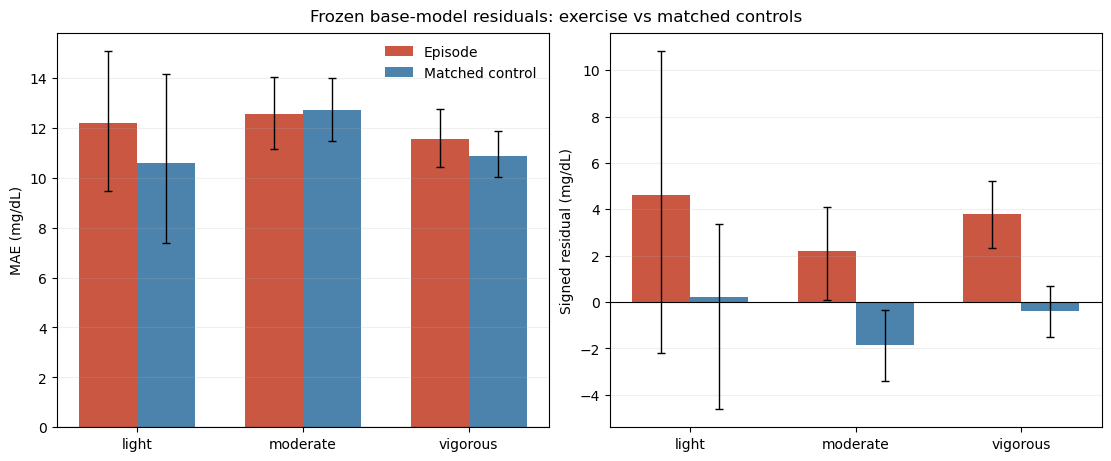

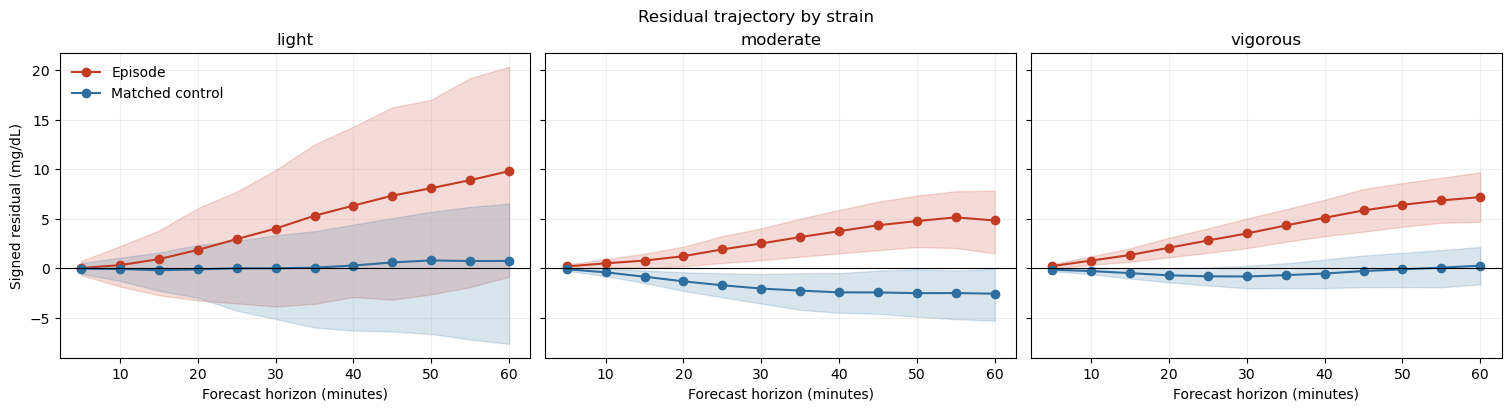

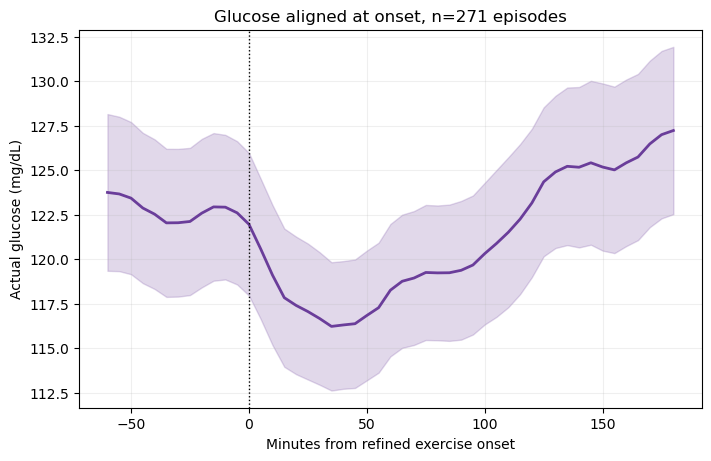

JUSTIFIED: moderate or vigorous episode residuals show material recoverable headroom over matched controls.

Outputs:
  arousal_exclusion_sensitivity.csv: 0.3 KiB
  diagnostic_verdict.json: 9.5 KiB
  episode_vs_control_residual_by_strain.pdf: 15.9 KiB
  episode_vs_control_residual_by_strain.png: 52.7 KiB
  glucose_aligned_at_onset.pdf: 14.8 KiB
  glucose_aligned_at_onset.png: 97.0 KiB
  matching_relaxation_sweep.csv: 0.3 KiB
  residual_comparison_summary.csv: 7.6 KiB
  residual_per_episode.parquet: 71.3 KiB
  residual_trajectory_by_horizon.pdf: 20.4 KiB
  residual_trajectory_by_horizon.png: 139.8 KiB
  residual_trajectory_summary.csv: 8.9 KiB


In [13]:
# Required per-episode output, restricted to primary pairs with at least one control.
control_per_episode = (
    primary_control_metrics.groupby("matched_episode_id", as_index=False)
    .agg(
        control_bias=("bias", "mean"),
        control_mae=("mae", "mean"),
        control_rmse=("rmse", "mean"),
        n_controls=("control_id", "nunique"),
    )
)
residual_per_episode = primary_episode_metrics.merge(
    control_per_episode,
    left_on="episode_id", right_on="matched_episode_id",
    how="left", validate="one_to_one"
)
episode_output_cols = [
    "episode_id", "participant_id", "split", "refined_start_time", "refined_end_time",
    "strain_class", "stratum", "cgm_at_start", "episode_confidence_class"
]
residual_per_episode = residual_per_episode.merge(
    analysis_with_cache[[c for c in episode_output_cols if c in analysis_with_cache]],
    on=["episode_id", "strain_class", "stratum"], how="left", validate="one_to_one",
)
residual_per_episode.to_parquet(OUTPUT_DIR / "residual_per_episode.parquet", index=False)

comparison_summary = pd.concat(
    [primary_summary, sensitivity_summary, insulin_summary],
    ignore_index=True,
)
comparison_summary.to_csv(OUTPUT_DIR / "residual_comparison_summary.csv", index=False)
primary_trajectory.to_csv(OUTPUT_DIR / "residual_trajectory_summary.csv", index=False)
arousal_exclusion_sensitivity.to_csv(OUTPUT_DIR / "arousal_exclusion_sensitivity.csv", index=False)
matching_relaxation_sweep.to_csv(OUTPUT_DIR / "matching_relaxation_sweep.csv", index=False)

# Figure 1: magnitude and signed bias by strain.
plot_strains = [s for s in ["light", "moderate", "vigorous"] if s in set(primary_summary["strain_class"])]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
x = np.arange(len(plot_strains))
width = 0.35
for ax, metric, ylabel in zip(axes, ["mae", "bias"], ["MAE (mg/dL)", "Signed residual (mg/dL)"]):
    tab = primary_summary.set_index("strain_class").loc[plot_strains]
    for offset, group, label, color in [
        (-width / 2, "episode", "Episode", "#c23b22"),
        ( width / 2, "control", "Matched control", "#2f6f9f"),
    ]:
        y = tab[f"{group}_{metric}"].to_numpy(float)
        lo = tab[f"{group}_{metric}_ci_low"].to_numpy(float)
        hi = tab[f"{group}_{metric}_ci_high"].to_numpy(float)
        ax.bar(x + offset, y, width, label=label, color=color, alpha=0.86)
        ax.errorbar(x + offset, y, yerr=np.vstack([y - lo, hi - y]), fmt="none", ecolor="black", capsize=3, lw=1)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x, plot_strains)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.2)
axes[0].legend(frameon=False)
fig.suptitle("Frozen base-model residuals: exercise vs matched controls")
for ext in ["png", "pdf"]:
    fig.savefig(OUTPUT_DIR / f"episode_vs_control_residual_by_strain.{ext}", dpi=180, bbox_inches="tight")
plt.show()

# Figure 2: residual trajectory across all 12 horizons, stratified by strain.
fig, axes = plt.subplots(1, max(1, len(plot_strains)), figsize=(5 * max(1, len(plot_strains)), 4), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, strain in zip(axes, plot_strains):
    tab = primary_trajectory[primary_trajectory["strain_class"].eq(strain)].sort_values("horizon_step")
    h = tab["horizon_minutes"].to_numpy(float)
    for group, label, color in [
        ("episode", "Episode", "#c23b22"),
        ("control", "Matched control", "#2f6f9f"),
    ]:
        y = tab[f"{group}_residual"].to_numpy(float)
        lo = tab[f"{group}_ci_low"].to_numpy(float)
        hi = tab[f"{group}_ci_high"].to_numpy(float)
        ax.plot(h, y, marker="o", label=label, color=color)
        ax.fill_between(h, lo, hi, color=color, alpha=0.18)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(strain)
    ax.set_xlabel("Forecast horizon (minutes)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Signed residual (mg/dL)")
axes[0].legend(frameon=False)
fig.suptitle("Residual trajectory by strain")
for ext in ["png", "pdf"]:
    fig.savefig(OUTPUT_DIR / f"residual_trajectory_by_horizon.{ext}", dpi=180, bbox_inches="tight")
plt.show()

# Figure 3: actual glucose aligned at refined onset.
offsets = np.arange(-60, 181, 5)
panel_plot = panel_raw[["participant_id", "timestamp_local", "cgm_glucose_mean"]].dropna(subset=["cgm_glucose_mean"]).copy()
panel_plot_by_pid = {
    pid: (_ns(g['timestamp_local']), g["cgm_glucose_mean"].to_numpy(float))
    for pid, g in panel_plot.groupby("participant_id", sort=False)
}
glucose_curves = []
for e in analysis_with_cache.itertuples(index=False):
    pid = str(e.participant_id)
    if pid not in panel_plot_by_pid:
        continue
    ts, values = panel_plot_by_pid[pid]
    query = pd.Timestamp(e.refined_start_time).value + offsets.astype(np.int64) * 60 * 1_000_000_000
    idx = np.searchsorted(ts, query)
    curve = np.full(len(offsets), np.nan)
    valid = (idx < len(ts))
    exact = valid & (ts[np.minimum(idx, len(ts) - 1)] == query)
    curve[exact] = values[idx[exact]]
    if np.isfinite(curve).sum() >= 12:
        glucose_curves.append(curve)
glucose_curves = np.asarray(glucose_curves)
mean_g = np.nanmean(glucose_curves, axis=0)
n_g = np.sum(np.isfinite(glucose_curves), axis=0)
sem_g = np.nanstd(glucose_curves, axis=0, ddof=1) / np.sqrt(np.maximum(n_g, 1))
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(offsets, mean_g, color="#6a3d9a", lw=2)
ax.fill_between(offsets, mean_g - 1.96 * sem_g, mean_g + 1.96 * sem_g, color="#6a3d9a", alpha=0.2)
ax.axvline(0, color="black", ls=":", lw=1)
ax.set_xlabel("Minutes from refined exercise onset")
ax.set_ylabel("Actual glucose (mg/dL)")
ax.set_title(f"Glucose aligned at onset, n={len(glucose_curves):,} episodes")
ax.grid(alpha=0.2)
for ext in ["png", "pdf"]:
    fig.savefig(OUTPUT_DIR / f"glucose_aligned_at_onset.{ext}", dpi=180, bbox_inches="tight")
plt.show()

verdict_payload = {
    "decision": decision,
    "provisional": provisional,
    "provisional_reasons": provisional_reasons,
    "verdict_text": f"{'PROVISIONAL ' if provisional else ''}{decision}: {explanation}.",
    "material_gap_threshold_mgdl": MATERIAL_GAP_MGDL,
    "decision_evidence": decision_evidence,
    "primary_counts": {
        "episodes_after_step0": int(len(analysis_episodes)),
        "episodes_with_cache_coverage": int(len(analysis_with_cache)),
        "episodes_with_matched_controls": int(len(matched_episode_ids)),
        "control_intervals": int(len(primary_controls)),
    },
    "provenance": provenance,
    "uncertain_arousal_exclusion_complete": uncertain_exclusion_complete,
    "arousal_exclusion_policy": primary_arousal_policy,
    "arousal_exclusion_rule": {
        "minimum_duration_minutes": AROUSAL_STRONG_MIN_DURATION_MIN,
        "minimum_mean_hr_excess_bpm": AROUSAL_STRONG_MIN_MEAN_HR_EXCESS,
    },
    "arousal_controls_equivalent": arousal_controls_equivalent,
    "selected_tod_tolerance_min": selected_tod_tolerance_min,
    "selected_glucose_tolerance_mgdl": selected_glucose_tolerance_mgdl,
    "matching_relaxation_sweep": matching_relaxation_sweep.replace({np.nan: None}).to_dict(orient="records"),
    "arousal_exclusion_sensitivity": arousal_exclusion_sensitivity.replace({np.nan: None}).to_dict(orient="records"),
    "per_strain": primary_summary.replace({np.nan: None}).to_dict(orient="records"),
}
(OUTPUT_DIR / "diagnostic_verdict.json").write_text(json.dumps(verdict_payload, indent=2))

print(verdict_payload["verdict_text"])
print("\nOutputs:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name}: {p.stat().st_size / 1024:.1f} KiB")

## Final result summary

This table collects the decision-driving moderate and vigorous results after proportionate uncertain-arousal exclusion.

In [14]:
final_rows = primary_summary[
    primary_summary["strain_class"].isin(["moderate", "vigorous"])
].copy()

final_result_table = pd.DataFrame({
    "Strain": final_rows["strain_class"].str.title(),
    "Matched episodes": final_rows["n_pairs"].astype(int),
    "Episode bias (mg/dL)": final_rows["episode_bias"],
    "Control bias (mg/dL)": final_rows["control_bias"],
    "Paired bias gap (mg/dL)": final_rows["paired_bias_gap"],
    "Paired bias gap 95% CI": final_rows.apply(
        lambda r: f"[{r['paired_bias_gap_ci_low']:.2f}, {r['paired_bias_gap_ci_high']:.2f}]", axis=1
    ),
    "Absolute bias headroom (mg/dL)": final_rows["absolute_bias_headroom"],
    "Headroom 95% CI": final_rows.apply(
        lambda r: f"[{r['absolute_bias_headroom_ci_low']:.2f}, {r['absolute_bias_headroom_ci_high']:.2f}]", axis=1
    ),
    "Headroom supported": final_rows["absolute_bias_headroom_ci_low"].gt(0).map({True: "Yes", False: "No"}),
})

numeric_cols = [
    "Episode bias (mg/dL)", "Control bias (mg/dL)",
    "Paired bias gap (mg/dL)", "Absolute bias headroom (mg/dL)",
]
display(final_result_table.style.format({c: "{:.2f}" for c in numeric_cols}).hide(axis="index"))
print(f"Verdict: {verdict_payload['verdict_text']}")
print(
    f"Coverage: {verdict_payload['primary_counts']['episodes_with_matched_controls']} / "
    f"{verdict_payload['primary_counts']['episodes_with_cache_coverage']} cache-covered episodes "
    f"({verdict_payload['primary_counts']['episodes_with_matched_controls'] / verdict_payload['primary_counts']['episodes_with_cache_coverage']:.1%})"
)
print(
    "Arousal exclusion: intervals lasting at least "
    f"{AROUSAL_STRONG_MIN_DURATION_MIN:.0f} minutes with mean HR excess at least "
    f"{AROUSAL_STRONG_MIN_MEAN_HR_EXCESS:.0f} bpm"
)

Strain,Matched episodes,Episode bias (mg/dL),Control bias (mg/dL),Paired bias gap (mg/dL),Paired bias gap 95% CI,Absolute bias headroom (mg/dL),Headroom 95% CI,Headroom supported
Moderate,102,2.20,-1.85,4.05,"[1.83, 6.29]",0.35,"[-2.29, 2.85]",No
Vigorous,104,3.82,-0.37,4.19,"[2.33, 5.97]",3.44,"[1.63, 4.91]",Yes


Verdict: JUSTIFIED: moderate or vigorous episode residuals show material recoverable headroom over matched controls.
Coverage: 212 / 271 cache-covered episodes (78.2%)
Arousal exclusion: intervals lasting at least 30 minutes with mean HR excess at least 20 bpm


=== FIGURE 1: Nadir depths by strain ===

  [primary]  271 episodes with sufficient glucose coverage
    light: n=  6 episodes | nadir drop = +34.1 mg/dL | time-to-nadir = 29 min
    moderate: n=118 episodes | nadir drop = +16.7 mg/dL | time-to-nadir = 28 min
    vigorous: n=147 episodes | nadir drop = +17.9 mg/dL | time-to-nadir = 33 min

  [all_incl_insulin]  412 episodes with sufficient glucose coverage
    light: n= 21 episodes | nadir drop = +21.0 mg/dL | time-to-nadir = 19 min
    moderate: n=182 episodes | nadir drop = +16.9 mg/dL | time-to-nadir = 28 min
    vigorous: n=200 episodes | nadir drop = +16.7 mg/dL | time-to-nadir = 33 min


/tmp/ipykernel_37149/2560796372.py:95: RuntimeWarning: Mean of empty slice
  pooled_baseline = float(np.nanmean(np.nanmean(curves[:, _pre_mask_s], axis=1)))
/tmp/ipykernel_37149/2560796372.py:64: RuntimeWarning: Mean of empty slice
  baselines = np.nanmean(curves[:, pre_mask], axis=1)


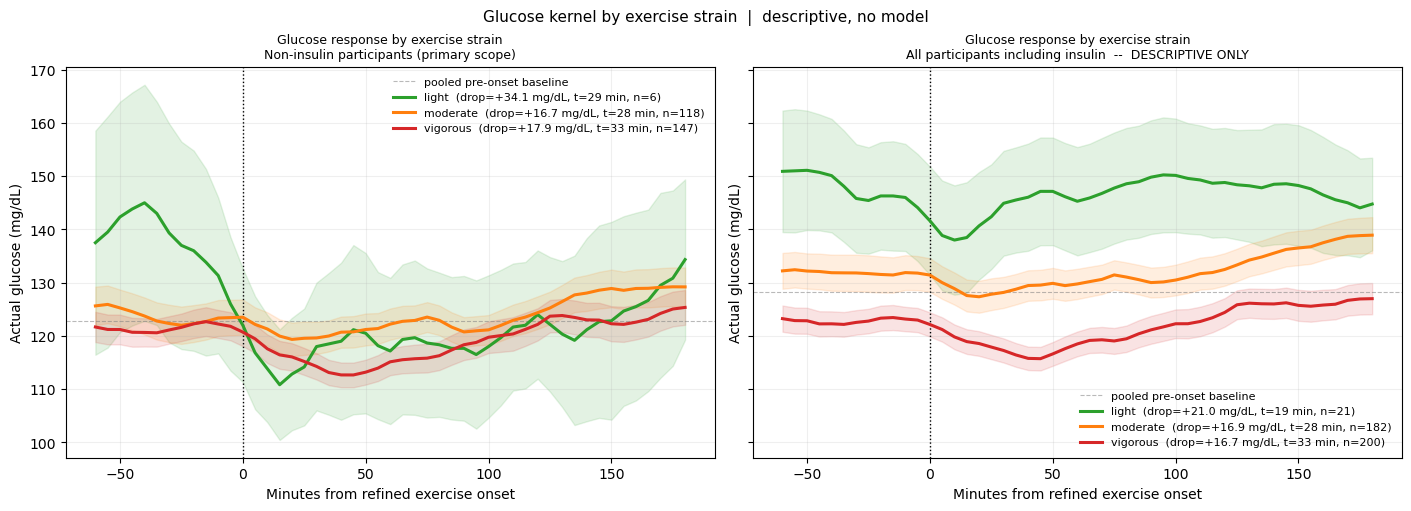

  Saved: glucose_kernel_by_strain.{png,pdf}

=== FIGURE 2: Glucose-drop vs HR-excess slopes (EXPLORATORY) ===
  Slope = mg/dL glucose drop per 1 BPM of mean HR-excess-stable.
  A blunted slope indicates less glucose reduction per unit exercise effort.
  EXPLORATORY -- confounders not controlled; interpret cautiously.

  normoglycemia: slope=-0.110 mg/dL/BPM  95% CI [-0.446, 0.225]  r=-0.066  p=0.5147  n=99
  prediabetes: slope=-0.124 mg/dL/BPM  95% CI [-0.689, 0.442]  r=-0.048  p=0.6650  n=84
  T2D-oral: slope=0.144 mg/dL/BPM  95% CI [-0.422, 0.709]  r=0.054  p=0.6144  n=88


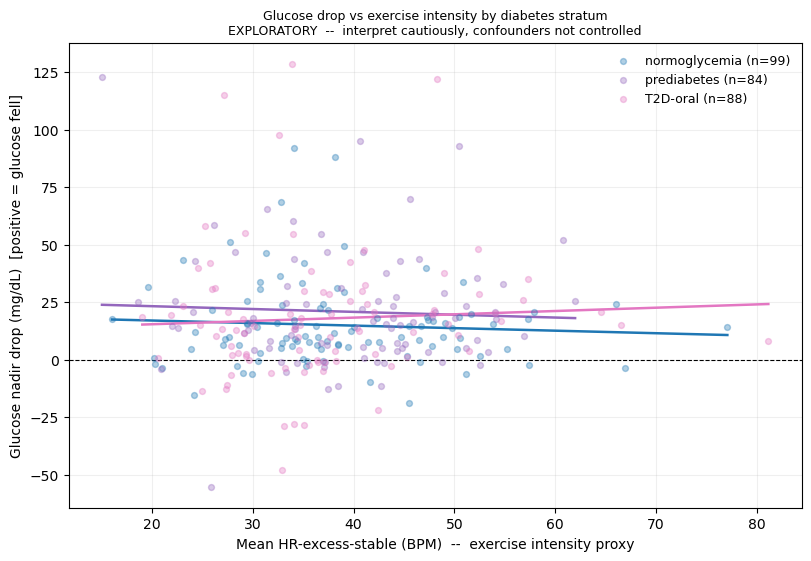

  Saved: glucose_drop_vs_hr_excess_by_stratum.{png,pdf}

  Slope summary table:
      stratum  n  slope_mgdl_per_bpm  ci_95_lo  ci_95_hi      r      p
normoglycemia 99              -0.110    -0.446     0.225 -0.066 0.5147
  prediabetes 84              -0.124    -0.689     0.442 -0.048 0.6650
     T2D-oral 88               0.144    -0.422     0.709  0.054 0.6144


In [15]:
# ── Glucose response by exercise strain: descriptive analysis ─────────────────
# Descriptive only. No model predictions used. Glucose aligned at refined onset.
# INPUT: analysis_with_cache, loose_episodes, panel_raw, OUTPUT_DIR already in scope.

from scipy import stats as _sp_stats

_STRAIN_COLORS = {"light": "#2ca02c", "moderate": "#ff7f0e", "vigorous": "#d62728"}
_STRAIN_ORDER  = ["light", "moderate", "vigorous"]
_STRATUM_COLORS = {
    "normoglycemia": "#1f77b4",
    "prediabetes":   "#9467bd",
    "T2D-oral":      "#e377c2",
}

# Rebuild glucose lookup (same logic as the pooled kernel above; self-contained).
_offsets_s = np.arange(-60, 181, 5)          # minutes relative to refined onset
_pre_mask_s   = _offsets_s < 0               # -60 to -5 min: pre-onset baseline
_post60_mask_s = (_offsets_s >= 0) & (_offsets_s <= 60)   # 0-60 min: nadir window

_panel_g = (
    panel_raw[["participant_id", "timestamp_local", "cgm_glucose_mean"]]
    .dropna(subset=["cgm_glucose_mean"])
    .copy()
)
_panel_by_pid_s = {
    pid: (_ns(grp["timestamp_local"]), grp["cgm_glucose_mean"].to_numpy(float))
    for pid, grp in _panel_g.groupby("participant_id", sort=False)
}


def _extract_aligned_curves(ep_df: pd.DataFrame):
    """Align each episode's glucose at refined onset; return arrays for all episodes."""
    curves, strains_out, strata_out, hr_out = [], [], [], []
    for e in ep_df.itertuples(index=False):
        pid = str(e.participant_id)
        if pid not in _panel_by_pid_s:
            continue
        ts, vals = _panel_by_pid_s[pid]
        query = (
            pd.Timestamp(e.refined_start_time).value
            + _offsets_s.astype(np.int64) * 60 * 1_000_000_000
        )
        idx = np.searchsorted(ts, query)
        curve = np.full(len(_offsets_s), np.nan)
        valid = idx < len(ts)
        exact = valid & (ts[np.minimum(idx, len(ts) - 1)] == query)
        curve[exact] = vals[idx[exact]]
        if np.isfinite(curve).sum() < 12:
            continue
        curves.append(curve)
        strains_out.append(str(getattr(e, "strain_class", "")))
        strata_out.append(str(getattr(e, "stratum", "")))
        hr_out.append(float(getattr(e, "mean_HR_excess_stable", np.nan)))
    return (
        np.asarray(curves),
        np.asarray(strains_out),
        np.asarray(strata_out),
        np.asarray(hr_out, dtype=float),
    )


def _nadir_drop_per_episode(curves, pre_mask, post_mask):
    """Return (baselines, drops, times_to_nadir) with NaN where data insufficient."""
    baselines = np.nanmean(curves[:, pre_mask], axis=1)
    post = curves[:, post_mask]
    has_post = np.sum(np.isfinite(post), axis=1) >= 3
    drops = np.full(len(curves), np.nan)
    ttns  = np.full(len(curves), np.nan)
    if has_post.any():
        nadir_idx = np.nanargmin(post[has_post], axis=1)
        nadir_vals = post[has_post][np.arange(has_post.sum()), nadir_idx]
        drops[has_post] = baselines[has_post] - nadir_vals   # positive = glucose fell
        ttns[has_post]  = _offsets_s[post_mask][nadir_idx]
    return baselines, drops, ttns


# ── FIGURE 1: Glucose kernel by strain ───────────────────────────────────────
# Left panel: primary non-insulin scope.  Right panel: all participants (descriptive).

fig1, (ax_prim, ax_all) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True, sharey=True)

print("=== FIGURE 1: Nadir depths by strain ===")

for ax, ep_df, panel_label, tag in [
    (ax_prim, analysis_with_cache,
     "Non-insulin participants (primary scope)",
     "primary"),
    (ax_all,  loose_episodes,
     "All participants including insulin  --  DESCRIPTIVE ONLY",
     "all_incl_insulin"),
]:
    curves, strain_arr, strata_arr, _ = _extract_aligned_curves(ep_df)
    print(f"\n  [{tag}]  {len(curves)} episodes with sufficient glucose coverage")

    pooled_baseline = float(np.nanmean(np.nanmean(curves[:, _pre_mask_s], axis=1)))
    ax.axhline(
        pooled_baseline,
        color="grey", ls="--", lw=0.8, alpha=0.55,
        label="pooled pre-onset baseline",
    )
    ax.axvline(0, color="black", ls=":", lw=1)

    for sc in _STRAIN_ORDER:
        sc_mask = strain_arr == sc
        if sc_mask.sum() < 3:
            continue
        sc_curves = curves[sc_mask]
        mean_c = np.nanmean(sc_curves, axis=0)
        n_c    = np.sum(np.isfinite(sc_curves), axis=0)
        sem_c  = np.nanstd(sc_curves, axis=0, ddof=1) / np.sqrt(np.maximum(n_c, 1))

        _, drops_ep, ttns_ep = _nadir_drop_per_episode(
            sc_curves, _pre_mask_s, _post60_mask_s
        )
        mean_drop = float(np.nanmean(drops_ep))
        mean_ttn  = float(np.nanmean(ttns_ep))

        print(
            f"    {sc}: n={sc_mask.sum():3d} episodes | "
            f"nadir drop = {mean_drop:+.1f} mg/dL | time-to-nadir = {mean_ttn:.0f} min"
        )

        color = _STRAIN_COLORS[sc]
        lbl = f"{sc}  (drop={mean_drop:+.1f} mg/dL, t={mean_ttn:.0f} min, n={sc_mask.sum()})"
        ax.plot(_offsets_s, mean_c, color=color, lw=2.2, label=lbl)
        ax.fill_between(
            _offsets_s,
            mean_c - sem_c, mean_c + sem_c,
            color=color, alpha=0.13,
        )

    ax.set_xlabel("Minutes from refined exercise onset")
    ax.set_ylabel("Actual glucose (mg/dL)")
    ax.set_title(f"Glucose response by exercise strain\n{panel_label}", fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.2)

fig1.suptitle("Glucose kernel by exercise strain  |  descriptive, no model", fontsize=11)
for ext in ["png", "pdf"]:
    fig1.savefig(
        OUTPUT_DIR / f"glucose_kernel_by_strain.{ext}", dpi=180, bbox_inches="tight"
    )
plt.show()
print("  Saved: glucose_kernel_by_strain.{png,pdf}")


# ── FIGURE 2: Glucose-drop vs HR-excess scatter (exploratory) ────────────────
# Per-episode nadir drop vs exercise intensity; one point per episode.
# Non-insulin strata only (consistent with primary analysis scope).

_curves2, _strains2, _strata2, _hr2 = _extract_aligned_curves(analysis_with_cache)
_baselines2, _drops2, _ttns2 = _nadir_drop_per_episode(
    _curves2, _pre_mask_s, _post60_mask_s
)

_both_ok = np.isfinite(_drops2) & np.isfinite(_hr2)
_drops_f   = _drops2[_both_ok]
_hr_f      = _hr2[_both_ok]
_strata_f  = _strata2[_both_ok]

print("\n=== FIGURE 2: Glucose-drop vs HR-excess slopes (EXPLORATORY) ===")
print(
    "  Slope = mg/dL glucose drop per 1 BPM of mean HR-excess-stable.\n"
    "  A blunted slope indicates less glucose reduction per unit exercise effort.\n"
    "  EXPLORATORY -- confounders not controlled; interpret cautiously.\n"
)

fig2, ax2 = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

present_strata = [s for s in ["normoglycemia", "prediabetes", "T2D-oral"]
                  if s in np.unique(_strata_f)]
slopes_rows = []

for stratum in present_strata:
    smask = _strata_f == stratum
    x_s = _hr_f[smask]
    y_s = _drops_f[smask]
    n_s = int(smask.sum())
    color = _STRATUM_COLORS.get(stratum, "#444444")

    ax2.scatter(x_s, y_s, color=color, alpha=0.35, s=18,
                label=f"{stratum} (n={n_s})", zorder=3)

    if n_s >= 5:
        res = _sp_stats.linregress(x_s, y_s)
        t_crit = _sp_stats.t.ppf(0.975, df=max(n_s - 2, 1))
        ci_lo = res.slope - t_crit * res.stderr
        ci_hi = res.slope + t_crit * res.stderr
        x_fit = np.linspace(float(x_s.min()), float(x_s.max()), 80)
        ax2.plot(x_fit, res.intercept + res.slope * x_fit, color=color, lw=1.8)
        slopes_rows.append({
            "stratum": stratum,
            "n": n_s,
            "slope_mgdl_per_bpm": round(float(res.slope), 3),
            "ci_95_lo": round(float(ci_lo), 3),
            "ci_95_hi": round(float(ci_hi), 3),
            "r": round(float(res.rvalue), 3),
            "p": round(float(res.pvalue), 4),
        })
        print(
            f"  {stratum}: slope={res.slope:.3f} mg/dL/BPM  "
            f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]  r={res.rvalue:.3f}  p={res.pvalue:.4f}  n={n_s}"
        )
    else:
        print(f"  {stratum}: n={n_s} -- insufficient for linear fit")

ax2.axhline(0, color="black", lw=0.8, ls="--")
ax2.set_xlabel("Mean HR-excess-stable (BPM)  --  exercise intensity proxy")
ax2.set_ylabel("Glucose nadir drop (mg/dL)  [positive = glucose fell]")
ax2.set_title(
    "Glucose drop vs exercise intensity by diabetes stratum\n"
    "EXPLORATORY  --  interpret cautiously, confounders not controlled",
    fontsize=9,
)
ax2.legend(frameon=False, fontsize=9)
ax2.grid(alpha=0.2)

for ext in ["png", "pdf"]:
    fig2.savefig(
        OUTPUT_DIR / f"glucose_drop_vs_hr_excess_by_stratum.{ext}", dpi=180, bbox_inches="tight"
    )
plt.show()
print("  Saved: glucose_drop_vs_hr_excess_by_stratum.{png,pdf}")

if slopes_rows:
    print("\n  Slope summary table:")
    print(pd.DataFrame(slopes_rows).to_string(index=False))


=== Figure 2b: adjusted slopes (controlling for pre-onset glucose) ===
  n episodes used: 271
  x = HR-excess residualized on pre-onset glucose
  y = glucose-drop residualized on pre-onset glucose
  Per-stratum slope = response sensitivity independent of baseline glucose

  normoglycemia: adj slope=-0.057 mg/dL/BPM  95% CI [-0.322, 0.208]  r=-0.043  p=0.6719  n=99
  prediabetes: adj slope=-0.007 mg/dL/BPM  95% CI [-0.437, 0.424]  r=-0.003  p=0.9749  n=84
  T2D-oral: adj slope=0.147 mg/dL/BPM  95% CI [-0.308, 0.602]  r=0.069  p=0.5213  n=88

  Full interaction model coefficients:
  Term                               coef        se    95%_lo    95%_hi         p
  intercept                       -36.364     8.323   -52.752   -19.976    0.0000 *
  HR_excess                        -0.059     0.178    -0.410     0.292    0.7419  
  baseline_glucose                  0.501     0.039     0.424     0.577    0.0000 *
  strat_prediabetes                -5.668    11.253   -27.824    16.489    0.614

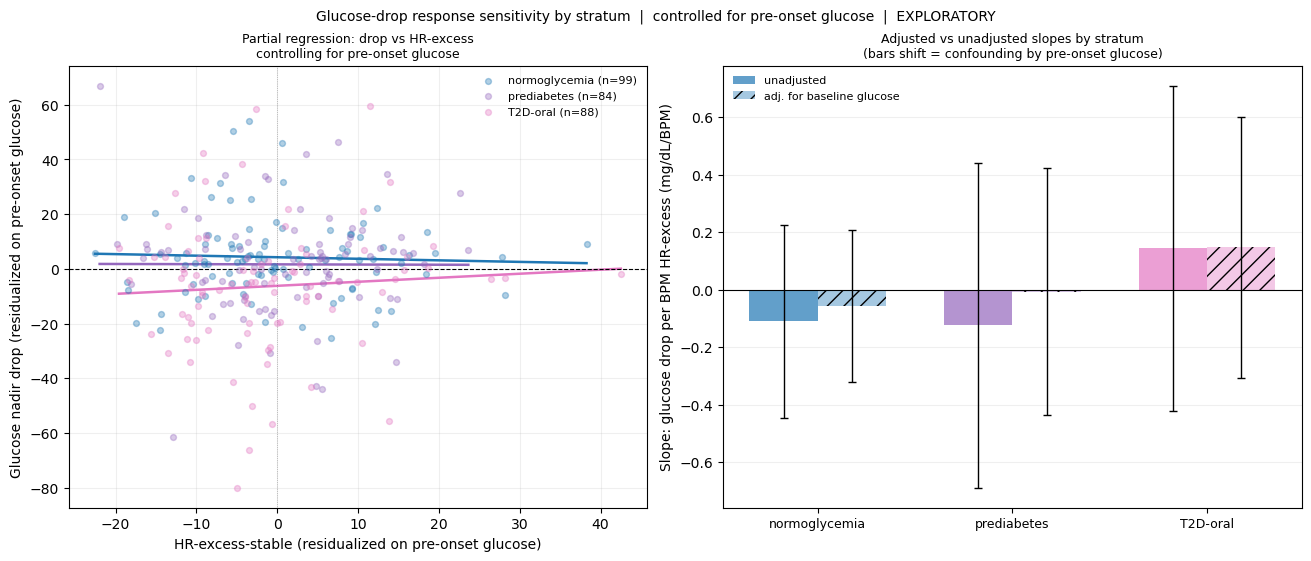

  Saved: glucose_drop_controlled_for_baseline.{png,pdf}


In [16]:
# ── Figure 2b: glucose-drop controlled for pre-onset glucose ─────────────────
# Extends Figure 2 by partialling out pre-onset glucose (the obvious confounder:
# higher pre-onset glucose -> more room to fall). Asks whether a stratum
# difference in response sensitivity survives the adjustment.
#
# Method 1 (visualization): partial regression (added-variable) plot.
#   Residualize both glucose-drop and HR-excess on pre-onset glucose (pooled OLS),
#   then plot and fit per-stratum lines on the residuals. The per-stratum slopes
#   on residualized data equal the HR-excess coefficient in a per-stratum
#   y ~ 1 + HR + baseline_glucose model (Frisch-Waugh-Lovell).
#
# Method 2 (formal): full OLS interaction model.
#   drop ~ 1 + HR + baseline_glucose + stratum_dummies + HR:stratum_dummies
#   Interaction coefficients = slope differences vs normoglycemia reference.
# EXPLORATORY -- interpret cautiously.

def _ols_resid(y: np.ndarray, *xs: np.ndarray) -> np.ndarray:
    """OLS residuals of y on [1, *xs]."""
    X = np.column_stack([np.ones(len(y)), *xs])
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ beta

def _ols_with_cov(y: np.ndarray, X: np.ndarray):
    """Return (beta, cov_matrix, sigma2) for design matrix X (no intercept added)."""
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, p = X.shape
    sigma2 = float(np.sum(resid ** 2) / max(n - p, 1))
    cov = sigma2 * np.linalg.pinv(X.T @ X)
    return beta, cov, sigma2

# ── Data: filter to episodes where drop, HR, and baseline are all finite ─────
_base_c = _baselines2[_both_ok]          # pre-onset baseline for same rows as _drops_f
_all_ok_c = np.isfinite(_drops_f) & np.isfinite(_hr_f) & np.isfinite(_base_c)
_y_c  = _drops_f[_all_ok_c]             # glucose nadir drop
_x_c  = _hr_f[_all_ok_c]               # mean HR-excess-stable
_z_c  = _base_c[_all_ok_c]             # pre-onset glucose (confounder)
_st_c = _strata_f[_all_ok_c]           # stratum label

_present_strata = [s for s in ["normoglycemia", "prediabetes", "T2D-oral"]
                   if s in np.unique(_st_c)]
N_TOT = len(_y_c)

# ── Method 1: partial regression plot ────────────────────────────────────────
_e_y = _ols_resid(_y_c, _z_c)     # drop residualized on pre-onset glucose
_e_x = _ols_resid(_x_c, _z_c)     # HR-excess residualized on pre-onset glucose

print("=== Figure 2b: adjusted slopes (controlling for pre-onset glucose) ===")
print(f"  n episodes used: {N_TOT}")
print(
    "  x = HR-excess residualized on pre-onset glucose\n"
    "  y = glucose-drop residualized on pre-onset glucose\n"
    "  Per-stratum slope = response sensitivity independent of baseline glucose\n"
)

adj_rows = []
for stratum in _present_strata:
    sm = _st_c == stratum
    ex_s, ey_s = _e_x[sm], _e_y[sm]
    n_s = int(sm.sum())
    if n_s < 5:
        print(f"  {stratum}: n={n_s} -- insufficient")
        continue
    res = _sp_stats.linregress(ex_s, ey_s)
    t_c = _sp_stats.t.ppf(0.975, df=max(n_s - 2, 1))
    lo, hi = res.slope - t_c * res.stderr, res.slope + t_c * res.stderr
    adj_rows.append(dict(
        stratum=stratum, n=n_s,
        adj_slope=round(float(res.slope), 3),
        ci_lo=round(float(lo), 3),
        ci_hi=round(float(hi), 3),
        r=round(float(res.rvalue), 3),
        p=round(float(res.pvalue), 4),
    ))
    print(
        f"  {stratum}: adj slope={res.slope:.3f} mg/dL/BPM  "
        f"95% CI [{lo:.3f}, {hi:.3f}]  r={res.rvalue:.3f}  p={res.pvalue:.4f}  n={n_s}"
    )

# ── Method 2: full interaction model ────────────────────────────────────────
# Stratum encoding: normoglycemia = reference (dropped)
_strat_idx = {s: i for i, s in enumerate(_present_strata)}
_ref = "normoglycemia"
_non_ref = [s for s in _present_strata if s != _ref]
_s_dummies = np.column_stack(
    [(_st_c == s).astype(float) for s in _non_ref]
) if _non_ref else np.zeros((N_TOT, 0))
_s_x_interact = _s_dummies * _x_c[:, None]

# Design: [1, HR, baseline_glucose, stratum_dummies, HR:stratum_dummies]
X_full = np.column_stack([np.ones(N_TOT), _x_c, _z_c, _s_dummies, _s_x_interact])
beta_f, cov_f, _ = _ols_with_cov(_y_c, X_full)

_p = X_full.shape[1]
t_crit_f = _sp_stats.t.ppf(0.975, df=max(N_TOT - _p, 1))
se_f = np.sqrt(np.diag(cov_f))

colnames = (
    ["intercept", "HR_excess", "baseline_glucose"]
    + [f"strat_{s}" for s in _non_ref]
    + [f"HR_excess:strat_{s}" for s in _non_ref]
)

print("\n  Full interaction model coefficients:")
print(f"  {'Term':<30} {'coef':>8}  {'se':>8}  {'95%_lo':>8}  {'95%_hi':>8}  {'p':>8}")
t_vals = beta_f / np.where(se_f > 0, se_f, np.nan)
p_vals = 2 * _sp_stats.t.sf(np.abs(t_vals), df=max(N_TOT - _p, 1))
for name, b, se, t_v, p_v in zip(colnames, beta_f, se_f, t_vals, p_vals):
    lo_i, hi_i = b - t_crit_f * se, b + t_crit_f * se
    star = "*" if p_v < 0.05 else (" " if not np.isnan(p_v) else "")
    print(f"  {name:<30} {b:>8.3f}  {se:>8.3f}  {lo_i:>8.3f}  {hi_i:>8.3f}  {p_v:>8.4f} {star}")

# Adjusted slopes per stratum from interaction model (for right panel)
int_model_slopes = {}
hr_idx = 1  # position of HR_excess in X_full
interact_start = 3 + len(_non_ref)  # where HR:stratum interactions begin
int_model_slopes[_ref] = (
    beta_f[hr_idx],
    np.sqrt(cov_f[hr_idx, hr_idx]),
)
for k, s in enumerate(_non_ref):
    int_idx = interact_start + k
    b_adj = beta_f[hr_idx] + beta_f[int_idx]
    var_adj = cov_f[hr_idx, hr_idx] + cov_f[int_idx, int_idx] + 2 * cov_f[hr_idx, int_idx]
    int_model_slopes[s] = (b_adj, np.sqrt(max(var_adj, 0.0)))

print("\n  Adjusted slopes from full interaction model:")
for s in _present_strata:
    b_s, se_s = int_model_slopes[s]
    lo_s = b_s - t_crit_f * se_s
    hi_s = b_s + t_crit_f * se_s
    print(f"  {s}: adj slope={b_s:.3f}  95% CI [{lo_s:.3f}, {hi_s:.3f}]")

# ── Figure ───────────────────────────────────────────────────────────────────
fig_c, (ax_scatter, ax_slopes) = plt.subplots(
    1, 2, figsize=(13, 5.5), constrained_layout=True
)

# Left: partial regression scatter
for stratum in _present_strata:
    sm = _st_c == stratum
    color = _STRATUM_COLORS.get(stratum, "#444")
    ex_s, ey_s = _e_x[sm], _e_y[sm]
    ax_scatter.scatter(ex_s, ey_s, color=color, alpha=0.35, s=18,
                       label=f"{stratum} (n={sm.sum()})", zorder=3)
    if sm.sum() >= 5:
        res = _sp_stats.linregress(ex_s, ey_s)
        x_fit = np.linspace(float(ex_s.min()), float(ex_s.max()), 80)
        ax_scatter.plot(x_fit, res.intercept + res.slope * x_fit,
                        color=color, lw=1.8)

ax_scatter.axhline(0, color="black", lw=0.8, ls="--")
ax_scatter.axvline(0, color="black", lw=0.5, ls=":", alpha=0.4)
ax_scatter.set_xlabel("HR-excess-stable (residualized on pre-onset glucose)")
ax_scatter.set_ylabel("Glucose nadir drop (residualized on pre-onset glucose)")
ax_scatter.set_title(
    "Partial regression: drop vs HR-excess\ncontrolling for pre-onset glucose",
    fontsize=9,
)
ax_scatter.legend(frameon=False, fontsize=8)
ax_scatter.grid(alpha=0.2)

# Right: adjusted slopes from partial regression vs unadjusted (from Figure 2)
# Collect unadjusted slopes for the same filtered sample
unadj_rows = {}
for stratum in _present_strata:
    sm = _st_c == stratum
    if sm.sum() >= 5:
        res_u = _sp_stats.linregress(_x_c[sm], _y_c[sm])
        t_cu = _sp_stats.t.ppf(0.975, df=max(sm.sum() - 2, 1))
        unadj_rows[stratum] = (
            float(res_u.slope),
            float(res_u.slope - t_cu * res_u.stderr),
            float(res_u.slope + t_cu * res_u.stderr),
        )

x_pos = np.arange(len(_present_strata))
width = 0.35
for offset, source_label, get_vals, hatch in [
    (-width / 2, "unadjusted", unadj_rows, ""),
    ( width / 2, "adj. for baseline glucose", None, "//"),
]:
    for i, stratum in enumerate(_present_strata):
        color = _STRATUM_COLORS.get(stratum, "#444")
        if source_label == "unadjusted":
            if stratum not in unadj_rows:
                continue
            slope, lo_v, hi_v = unadj_rows[stratum]
        else:
            row = next((r for r in adj_rows if r["stratum"] == stratum), None)
            if row is None:
                continue
            slope, lo_v, hi_v = row["adj_slope"], row["ci_lo"], row["ci_hi"]
        ax_slopes.bar(
            i + offset, slope, width,
            color=color, alpha=0.7 if source_label == "unadjusted" else 0.4,
            hatch=hatch,
            label=source_label if i == 0 else None,
        )
        ax_slopes.errorbar(
            i + offset, slope,
            yerr=np.array([[slope - lo_v], [hi_v - slope]]),
            fmt="none", ecolor="black", capsize=3, lw=1,
        )

ax_slopes.axhline(0, color="black", lw=0.8)
ax_slopes.set_xticks(x_pos, _present_strata, fontsize=9)
ax_slopes.set_ylabel("Slope: glucose drop per BPM HR-excess (mg/dL/BPM)")
ax_slopes.set_title(
    "Adjusted vs unadjusted slopes by stratum\n"
    "(bars shift = confounding by pre-onset glucose)",
    fontsize=9,
)
ax_slopes.legend(frameon=False, fontsize=8)
ax_slopes.grid(axis="y", alpha=0.2)

fig_c.suptitle(
    "Glucose-drop response sensitivity by stratum  |  controlled for pre-onset glucose"
    "  |  EXPLORATORY",
    fontsize=10,
)
for ext in ["png", "pdf"]:
    fig_c.savefig(
        OUTPUT_DIR / f"glucose_drop_controlled_for_baseline.{ext}",
        dpi=180, bbox_inches="tight",
    )
plt.show()
print("  Saved: glucose_drop_controlled_for_baseline.{png,pdf}")
